<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/4_modulo/4_modulo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/4_modulo/4_modulo.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

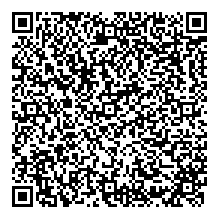

In [1]:
# QR para el cuaderno de clase que permite lectura activa y experimental
import qrcode
from PIL import Image
import os

# URL del notebook en GitHub
url = "https://colab.research.google.com/github/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/4_modulo/4_modulo.ipynb"

# Configuración del QR
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=3,
    border=4,
)

# Añadir datos al QR
qr.add_data(url)
qr.make(fit=True)

# Crear imagen del QR
img = qr.make_image(fill_color="black", back_color="white")

# Guardar imagen
output_path = "github_notebook_qr.png"
img.save(output_path)

# Mostrar imagen generada (solo si se ejecuta en Jupyter Notebook/Lab)
try:
    display(Image.open(output_path))
except:
    print(f"Código QR generado y guardado en: {os.path.abspath(output_path)}")
    print("Ábralo con cualquier visor de imágenes o escanéelo con su móvil.")
    img.show()  # Abre la imagen en el visor predeterminado



### [Video de apoyo a la lectura del módulo 4 del texto de Clara Mejía Laverde](https://www.youtube.com/watch?v=P-A2BjQmEgA)

[Video de presentación en tableta digital de algún ejemplo del módulo 4: Cómo resolver un sistema con Gauss Jordan](https://www.youtube.com/watch?v=KWFJFEQhTww)

[Video de apoyo a la presentación del ejemplo 2 de este módulo 4 con tableta](https://www.youtube.com/watch?v=Hi_c--dtMg0)

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno](https://www.youtube.com/watch?v=SKzvZyACoNg)

[Presentación del módulo 4: Independencia lineal pero con el enfoque de ciencia de datos con Python](https://www.youtube.com/watch?v=iy_Eji5JzOU)

### [Vínculo al programa del curso: Linear_Algebra ](https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/0_programa_cronograma_curso/1_programa_linear_algebra/1_programa_linear_algebra.md)



#### Código del curso: 5009329

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/linear_algebra/blob/main/images/geo_vectorial_ultima_clase_2025-11-04.jpg?raw=true' width = 300> 



In [5]:
import pandas as pd
import numpy as np

# Cargar la lista de estudiantes desde el archivo CSV
path = 'C:/Users/marco/Documentos/docencia/groups_list/linear_algebra.xlsx'
df = pd.read_excel(path)
df.index = range(1, len(df) + 1)
df.head(11) 


,Cédula,Nombre,Email
1,1007676529,ARENAS HERAZO GABRIEL ENRIQUE,gabriel.arenas@udea.edu.co
2,1038547924,ARROYAVE ECHAVARRIA LAURA SOFIA,sofia.arroyave@udea.edu.co
3,1007528664,AYALA MENDOZA MARISOL YACIRA,marisol.ayala@udea.edu.co
4,1007676170,CANTILLO ENSUCHO DANIEL,daniel.cantillo@udea.edu.co
5,1038104030,IBAÑEZ MORENO FRANCISCO LUIS,francisco.ibanez@udea.edu.co
6,1066570075,MONTERROSA SOTO ABRIL,a.monterrosa@udea.edu.co
7,1038099623,NORIEGA JIMENEZ GABRIELA,gabriela.noriega@udea.edu.co
8,1129805618,PEREZ THERAN ERLINDA,erlinda.perez@udea.edu.co
9,1038101968,QUINONEZ CERVANTES MARIANA,mariana.quinonezc@udea.edu.co
10,1007318378,RAMOS PEREZ YANINE,y.ramos@udea.edu.co


# Módulo 4 Independencia lineal.    




* [Álgebra Lineal de Clara Elena Mejía Laverde](https://www.academia.edu/43065939/Alg_Lineal_Clara_Mejia_Universidad_de_Ant) 

In [2]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -------------------------
# VECTORES
# -------------------------

v1 = np.array([2,1,1])
v2 = np.array([4,2,2])   # paralelo a v1

u1 = np.array([2,1,0])
u2 = np.array([0,2,1])   # no paralelo

# -------------------------
# FIGURA CON DOS ESCENAS
# -------------------------

fig = make_subplots(
rows=1, cols=2,
specs=[[{'type':'scene'}, {'type':'scene'}]],
subplot_titles=("Vectores paralelos → Recta",
                "Vectores no paralelos → Plano")
)

# -------------------------
# FUNCION EJES
# -------------------------

def axes(scene_col):

    L=4
    
    fig.add_trace(go.Scatter3d(
        x=[0,L],y=[0,0],z=[0,0],
        mode='lines',
        line=dict(color='red',width=6),
        showlegend=False),
        row=1,col=scene_col)

    fig.add_trace(go.Scatter3d(
        x=[0,0],y=[0,L],z=[0,0],
        mode='lines',
        line=dict(color='green',width=6),
        showlegend=False),
        row=1,col=scene_col)

    fig.add_trace(go.Scatter3d(
        x=[0,0],y=[0,0],z=[0,L],
        mode='lines',
        line=dict(color='blue',width=6),
        showlegend=False),
        row=1,col=scene_col)

# -------------------------
# EJES
# -------------------------

axes(1)
axes(2)

# -------------------------
# CASO 1: RECTA
# -------------------------

t=np.linspace(-2,2,50)

line=np.outer(t,v1)

fig.add_trace(go.Scatter3d(
x=line[:,0],
y=line[:,1],
z=line[:,2],
mode='lines',
line=dict(width=8,color='black'),
name='Recta generada'
),row=1,col=1)

# vectores

for v in [v1,v2]:

    fig.add_trace(go.Scatter3d(
    x=[0,v[0]],
    y=[0,v[1]],
    z=[0,v[2]],
    mode='lines+markers',
    marker=dict(size=3),
    line=dict(width=10),
    showlegend=False
    ),row=1,col=1)

    fig.add_trace(go.Cone(
    x=[v[0]],
    y=[v[1]],
    z=[v[2]],
    u=[v[0]],
    v=[v[1]],
    w=[v[2]],
    sizemode="absolute",
    sizeref=0.4,
    showscale=False
    ),row=1,col=1)

# -------------------------
# CASO 2: PLANO
# -------------------------

s=np.linspace(-1.5,1.5,10)
t=np.linspace(-1.5,1.5,10)

S,T=np.meshgrid(s,t)

plane = np.zeros((10,10,3))

for i in range(10):
    for j in range(10):
        plane[i,j] = S[i,j]*u1 + T[i,j]*u2

fig.add_trace(go.Surface(
x=plane[:,:,0],
y=plane[:,:,1],
z=plane[:,:,2],
opacity=0.6,
showscale=False
),row=1,col=2)

# vectores del plano

for v in [u1,u2]:

    fig.add_trace(go.Scatter3d(
    x=[0,v[0]],
    y=[0,v[1]],
    z=[0,v[2]],
    mode='lines+markers',
    marker=dict(size=3),
    line=dict(width=10),
    showlegend=False
    ),row=1,col=2)

    fig.add_trace(go.Cone(
    x=[v[0]],
    y=[v[1]],
    z=[v[2]],
    u=[v[0]],
    v=[v[1]],
    w=[v[2]],
    sizemode="absolute",
    sizeref=0.4,
    showscale=False
    ),row=1,col=2)

# -------------------------
# LAYOUT
# -------------------------

fig.update_layout(
height=600,
width=1100,
title="Subespacios generados por vectores en $R^3$"
)

fig.show()

fig.write_image(r"C:\Users\marco\Downloads\parallel_non_parallel_vectors.png")

## Contenidos del módulo  



1. Definición y ejemplos de conjuntos linealmente independientes (LI) y linealmente dependientes (LD)


2. Interpretación geométrica de la dependencia lineal en $\mathbb{R}^{3}$. 

 
3. Propiedades

## Objetivos del módulo  



1. Establecer los conceptos de dependencia e independencia lineal.


2. Interpretar geométricamente el significado de la dependencia lineal en $\mathbb{R}^{3}$.


3. Vincular la teoría de espacios vectoriales con los sistemas de ecuaciones lineales y los determinantes.

# Preguntas básicas


1. ¿Cuándo un conjunto es LD?


2. ¿Cuándo un conjunto es LI?


3. ¿Qué significa que un subconjunto de tres vectores de $\mathbb{R}^{3}$ es LD.  


4. ¿Tiene sentido hablar de un vector LI?  
    
   Un vector $v$ es LI si la única manera de obtener el cero por combinación lineal de él, es con la forma trivial $cv = 0$, con $c = 0$. Si $c$ puede ser diferente de cero, entonces el vector es LD. Mientras que si $c$ tiene que ser cero, entonces el vector es LI. 


5. ¿Por qué los conceptos de independencia y dependencia lineal se vinculan con la solución de sistemas homogéneos de ecuaciones lineales?

# Introducción  



En el módulo anterior vimos que pueden tenerse infinitud de conjuntos generadores de un espacio vectorial.   



Es claro, por razones de economía, que lo que se desea es hallar los conjuntos generadores más pequeños posibles para los espacios vectoriales.   



Para lograr esto se requiere el concepto de independencia lineal.  



Mostraremos el significado de independencia lineal y su relación con la teoría de sistemas homogéneos de ecuaciones y determinantes.

# Definición y ejemplos de conjuntos linealmente independientes (LI) y linealmente dependientes (LD)  



# Definición 1  

Sean $\mathbf{v}_{1}, \mathbf{v}_{2}, \ldots, \mathbf{v}_{n}$, $n$ vectores diferentes de un espacio vectorial $V$. 

Se dice que los vectores son *linealmente dependientes*, LD, si existen $n$ escalares $c_{1}, c_{2}, \ldots, c_{n}$ **no todos cero**, tales que: 

$$
c_{1}\mathbf{v}_{1} + c_{2}\mathbf{v}_{2} + \cdots + c_{n}\mathbf{v}_{n} = \mathbf{0}
$$

Si los vectores no son linealmente dependientes, se dice que son linealmente independientes, LI, es decir, la ecuación:   
 

$$
c_{1}\mathbf{v}_{1} + c_{2}\mathbf{v}_{2} + \cdots + c_{n}\mathbf{v}_{n} = \mathbf{0}
$$

es válida sólo si $c_{1} = c_{2} = \cdots = c_{n} = 0$.   



Si los vectores $\mathbf{v}_{1}, \mathbf{v}_{2}, \ldots, \mathbf{v}_{n}$ son distintos y formamos el conjunto $A = \{\mathbf{v}_{1}, \mathbf{v}_{2}, \ldots, \mathbf{v}_{n}\}$
entonces también decimos que el conjunto $A$ es LD o LI según el caso.  



Es claro que la ecuación $c_{1}\mathbf{v}_{1} + c_{2}\mathbf{v}_{2} + \cdots + c_{n}\mathbf{v}_{n} = \mathbf{0}$ siempre se satisface si elegimos todos los escalares $c_{1}, c_{2}, \ldots, c_{n}$  iguales a cero.  

Lo  importante es ver si es posible satisfacer la ecuación con al menos uno de los escalares diferente de cero.

# Ejemplos  



# 1. En $\mathbb{R}^{3}$, sea $A = \{(1, 7, -2), (-1, 1, 0), (3,5.-2)\}$ veamos si $A$ es LI o LD.   

### [Video de apoyo a el estudio de este ejemplo](https://www.youtube.com/watch?v=KWFJFEQhTww)

In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------
# VECTORES
# -----------------------

v1 = np.array([1,7,-2])
v2 = np.array([-1,1,0])
v3 = np.array([3,5,-2])

# -----------------------
# FIGURA
# -----------------------

fig = make_subplots(
rows=1, cols=2,
specs=[[{'type':'scene'}, {'type':'scene'}]],
subplot_titles=("Vectores en $R^3$",
                "Plano generado por los vectores")
)

# -----------------------
# EJES COORDENADOS
# -----------------------

def draw_axes(col):

    L = 8

    fig.add_trace(go.Scatter3d(
        x=[0,L], y=[0,0], z=[0,0],
        mode='lines',
        line=dict(color='red', width=6),
        showlegend=False
    ), row=1, col=col)

    fig.add_trace(go.Scatter3d(
        x=[0,0], y=[0,L], z=[0,0],
        mode='lines',
        line=dict(color='green', width=6),
        showlegend=False
    ), row=1, col=col)

    fig.add_trace(go.Scatter3d(
        x=[0,0], y=[0,0], z=[0,L],
        mode='lines',
        line=dict(color='blue', width=6),
        showlegend=False
    ), row=1, col=col)

draw_axes(1)
draw_axes(2)

# -----------------------
# FUNCION PARA VECTORES
# -----------------------

def draw_vector(v, col):

    fig.add_trace(go.Scatter3d(
        x=[0,v[0]],
        y=[0,v[1]],
        z=[0,v[2]],
        mode='lines+markers',
        marker=dict(size=3),
        line=dict(width=10),
        showlegend=False
    ), row=1, col=col)

    fig.add_trace(go.Cone(
        x=[v[0]],
        y=[v[1]],
        z=[v[2]],
        u=[v[0]],
        v=[v[1]],
        w=[v[2]],
        sizemode="absolute",
        sizeref=0.6,
        showscale=False
    ), row=1, col=col)

# -----------------------
# GRAFICO 1: VECTORES
# -----------------------

for v in [v1, v2, v3]:
    draw_vector(v,1)

# -----------------------
# PLANO
# -----------------------

s = np.linspace(-1.5,1.5,15)
t = np.linspace(-1.5,1.5,15)

S,T = np.meshgrid(s,t)

plane = np.zeros((15,15,3))

for i in range(15):
    for j in range(15):
        plane[i,j] = S[i,j]*v1 + T[i,j]*v2

fig.add_trace(go.Surface(
    x=plane[:,:,0],
    y=plane[:,:,1],
    z=plane[:,:,2],
    opacity=0.6,
    showscale=False
), row=1, col=2)

# vectores sobre el plano

for v in [v1, v2, v3]:
    draw_vector(v,2)

# -----------------------
# LAYOUT
# -----------------------

fig.update_layout(
title="Vectores y plano generado en $R^3$",
height=650,
width=1100
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\vectors_and_plane.png")

## Solución:  



Comenzamos planteando la ecuación 

$$ 
c_{1}(1, 7, -2) + c_{2}(-1, 1, 0) + c_{3}(3, 5, -2) = (0,0,0)
$$  



la cual, igualando los componentes en ambos lados de la ecuación, nos lleva al siguiente sistema homogéneo de ecuaciones:  

$$
\begin{align}
c_{1} -c_{2} + 3c_{3} & = 0 \\  
7c_{1} + c_{2} + 5c_{3} & = 0  \\  
-2c_{1} - 2c_{3} & = 0   
\end{align}
$$


# 1. Resolución simbólica directa con **SymPy**

Este enfoque imita el procedimiento algebraico clásico.


In [2]:
import sympy as sp

# Variables
c1, c2, c3 = sp.symbols('c1 c2 c3')

# Sistema
ecuaciones = [
    c1 - c2 + 3*c3,
    7*c1 + c2 + 5*c3,
    -2*c1 - 2*c3
]

# Resolver
solucion = sp.solve(ecuaciones, [c1, c2, c3])
solucion


{c1: -c3, c2: 2*c3}

La solución obtenida del sistema es: 

$$
S = \{(c_{1}, c_{2}, c_{3}) \mid c_{1} = -c_{3}, \ c_{2} = 2c_{3}, \ c_{3} \in \mathbb{R}\}
$$  



$$
S = \left\{  \begin{pmatrix}c_{1}\\ c_{2} \\ c_{3} \end{pmatrix} \mid c_{3} \begin{pmatrix}-1\\ 2\\ 1 \end{pmatrix}, c_{3} \in \mathbb{R} \right\}
$$

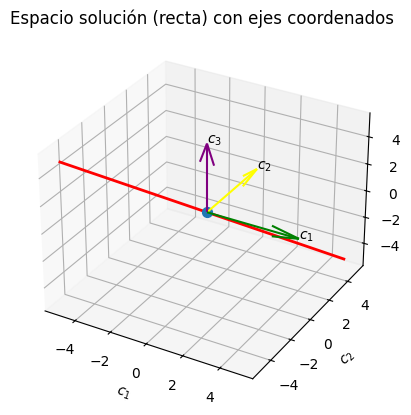

<Figure size 640x480 with 0 Axes>

In [3]:
# Graficamos la solución del sistema 

import numpy as np
import matplotlib.pyplot as plt

# Vector director del espacio solución
v = np.array([-1, -1, 1])

# Parámetro
t = np.linspace(-5, 5, 100)

# Recta solución
x = t * v[0]
y = t * v[1]
z = t * v[2]

# Figura 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Recta solución
ax.plot(x, y, z, linewidth=2, color = 'red')
ax.scatter(0, 0, 0, s=50)  # origen

# Ejes coordenados
axis_len = 5
ax.quiver(0, 0, 0, axis_len, 0, 0, color = 'green')
ax.quiver(0, 0, 0, 0, axis_len, 0, color = 'yellow')
ax.quiver(0, 0, 0, 0, 0, axis_len, color = 'purple')

ax.text(axis_len, 0, 0, r'$c_1$')
ax.text(0, axis_len, 0, r'$c_2$')
ax.text(0, 0, axis_len, r'$c_3$')

ax.set_xlabel(r'$c_1$')
ax.set_ylabel(r'$c_2$')
ax.set_zlabel(r'$c_3$')

ax.set_title('Espacio solución (recta) con ejes coordenados')

plt.show()

ax.set_xlabel(r'$c_1$')
ax.set_ylabel(r'$c_2$')
ax.set_zlabel(r'$c_3$')

ax.set_title('Espacio solución del sistema homogéneo')
plt.savefig(r"C:\Users\marco\Downloads\espacio_solucion_sistema_homogeneo.png")
plt.show()


In [4]:
import plotly.graph_objects as go
import numpy as np

# Vector director
v = np.array([-1, -1, 1])

# Parámetro
t = np.linspace(-5, 5, 100)

# Recta solución
x = t * v[0]
y = t * v[1]
z = t * v[2]

fig = go.Figure()

# Recta solución
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z,
    mode='lines',
    name='Espacio solución'
))

# Origen
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    name='Origen'
))

# Ejes coordenados
axis_len = 5
fig.add_trace(go.Scatter3d(
    x=[0, axis_len], y=[0, 0], z=[0, 0],
    mode='lines',
    name='Eje c1'
))

fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, axis_len], z=[0, 0],
    mode='lines',
    name='Eje c2'
))

fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[0, axis_len],
    mode='lines',
    name='Eje c3'
))

fig.update_layout(
    title='Espacio solución del sistema homogéneo',
    scene=dict(
        xaxis_title='c1',
        yaxis_title='c2',
        zaxis_title='c3'
    )
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\espacio_solucion.png")


Un ejemplo de solución es $c_{3} = 0$, entonces $c_{1} = 0$ y $c_{2} = 0$. Y otra solición es si $c_{3} = 1$, entonces $c_{1} = -1$ y $c_{2} = 2$. 

Por lo tanto, $A$ es un conjunto LD. 


- **Interpretación**
SymPy te da la solución paramétrica automáticamente (si existe un espacio de soluciones no trivial).

---



# 2. Forma matricial y **espacio nulo (nullspace)**



Este es el enfoque **conceptualmente más importante en álgebra lineal**.

## Sistema en forma matricial

$$
A\mathbf{c} = 0
$$



In [5]:
A = sp.Matrix([
    [1, -1,  3],
    [7,  1,  5],
    [-2, 0, -2]
])

# Espacio nulo
null = A.nullspace()
null


[Matrix([
 [-1],
 [ 2],
 [ 1]])]


- **Resultado**

* `nullspace()` devuelve una **base del espacio de soluciones**
* Cada vector representa una solución independiente. 



- La solución general es una combinación lineal de esos vectores.

---



# 3. Reducción por filas (Gauss–Jordan)



Ideal para mostrar el método clásico, pero automatizado.


In [6]:
A_aumentada = A.row_join(sp.zeros(3, 1))  # matriz aumentada
A_aumentada

Matrix([
[ 1, -1,  3, 0],
[ 7,  1,  5, 0],
[-2,  0, -2, 0]])

In [ ]:
A_rref, pivots = A_aumentada.rref()

A_rref, pivots # que es lo que el componente pivots representa
# El componente pivots representa las columnas que contienen los pivotes en la matriz reducida por filas (rref). 
# En este caso, los pivotes están en las columnas 0 y 1, lo que indica que las variables correspondientes a esas 
# columnas son las variables básicas, mientras que la variable correspondiente a la columna 2 es una variable libre.


(Matrix([
 [1, 0,  1, 0],
 [0, 1, -2, 0],
 [0, 0,  0, 0]]),
 (0, 1))

- Aquí puedes:

* Identificar variables libres
* Construir la solución paso a paso como en el tablero

---



# 4. Resolución numérica con **NumPy** (SVD)

En sistemas homogéneos, NumPy no usa `solve`, sino **descomposición en valores singulares**.


In [7]:
import numpy as np

A_np = np.array([
    [1, -1,  3],
    [7,  1,  5],
    [-2, 0, -2]
], dtype=float)

# SVD
U, S, Vt = np.linalg.svd(A_np)

# Vector asociado al valor singular más pequeño
null_vec = Vt[-1]
null_vec


array([ 0.40824829, -0.81649658, -0.40824829])


- **Clave conceptual**

* El último vector de `Vt` genera el **espacio nulo**
* Es una solución **aproximada**, pero muy útil en ciencia de datos y ML

---



# 5. Verificación automática de la solución

Siempre bonito cerrar con verificación:


In [6]:
null[0]

Matrix([
[-1],
[ 2],
[ 1]])

In [13]:
A @ null[0]


Matrix([
[0],
[0],
[0]])

o en NumPy:


In [14]:
A_np @ null_vec


array([ 4.44089210e-16,  3.10862447e-15, -8.88178420e-16])


Debe dar el **vector cero** (o muy cercano).

---



# 6. Interpretación matemática final

* Es un **sistema homogéneo**
* Tiene soluciones no triviales ⇔ `det(A) = 0`
* El conjunto solución es un **subespacio vectorial** de ℝ³
* En este caso, es una **recta que pasa por el origen**

---


# 2. En $\mathbb{P}_{2}$, sea $B = \{-1 + x^{2}, 2+x, x^{2}\}$. ¿Es $B$ LI o LD?.  


[Video de apoyo a la presentación de este ejemplo con tableta](https://www.youtube.com/watch?v=Hi_c--dtMg0)


## Solución:  

Dada la ecuación

$$
c_{1}(-1+x^{2}) + c_{2}(2+x) + c_{3}(x^{2}) = 0 + 0x + 0x^{2}.  
$$

Veamos cómo son $c_{1}, c_{2}$ y $c_{3}$.  

Empecemos aplicando propiedad distributiva de la multiplicación con respecto a la suma: 

$$
-c_{1} + c_{1}x^{2} + 2c_{2} + c_{2}x + c_{3}x^{2} = 0 + 0x + 0x^{2}
$$  



Sumemos términos semejantes: 

$$
(-c_{1} + 2c_{2}) + (c_{2})x + (c_{1}+ c_{3})x^{2} = 0 + 0x + 0x^{2}
$$



Apliquemos el principio de igualdad de polinomios: 

$$
\begin{align}
-c_{1} + 2c_{2} & = 0 \\  
c_{2}           & = 0 \\  
c_{1} + c_{3}   & = 0 
\end{align}
$$

de donde $c_{1} = c_{2} = c_{3} = 0$. De donde, $B$ es LI. 

In [8]:
# dame una representación con plotliy de las funciones del conjunto B # 2. En $\mathbb{P}_{2}$, sea $B = \{-1 + x^{2}, 2+x, x^{2}\}$. ¿Es $B$ LI o LD?.  
# y a la derecha de este gráfico los vectores de R3 asociados a cada función del conjunto B y el plano que contiene a dos de estos vectores.

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dominio
x = np.linspace(-4,4,200)

f1 = -1 + x**2
f2 = 2 + x
f3 = x**2

# Vectores asociados
v1 = np.array([-1,0,1])
v2 = np.array([2,1,0])
v3 = np.array([0,0,1])

# Figura con dos paneles
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type":"xy"},{"type":"scene"}]],
    subplot_titles=("Funciones del conjunto B", "Vectores asociados en R3")
)

# --- FUNCIONES ---
fig.add_trace(go.Scatter(x=x,y=f1,mode='lines',name='-1 + x²'),row=1,col=1)
fig.add_trace(go.Scatter(x=x,y=f2,mode='lines',name='2 + x'),row=1,col=1)
fig.add_trace(go.Scatter(x=x,y=f3,mode='lines',name='x²'),row=1,col=1)

# --- VECTORES ---
def vector_trace(v,name):
    return go.Scatter3d(
        x=[0,v[0]],
        y=[0,v[1]],
        z=[0,v[2]],
        mode='lines+markers',
        line=dict(width=6),
        name=name
    )

fig.add_trace(vector_trace(v1,"-1 + x²"),row=1,col=2)
fig.add_trace(vector_trace(v2,"2 + x"),row=1,col=2)
fig.add_trace(vector_trace(v3,"x²"),row=1,col=2)

# --- PLANO generado por v1 y v2 ---
s = np.linspace(-1.5,1.5,10)
t = np.linspace(-1.5,1.5,10)

S,T = np.meshgrid(s,t)

X = v1[0]*S + v2[0]*T
Y = v1[1]*S + v2[1]*T
Z = v1[2]*S + v2[2]*T

fig.add_trace(
    go.Surface(x=X,y=Y,z=Z,opacity=0.5,showscale=False,name="Plano(v1,v2)"),
    row=1,col=2
)

fig.update_layout(
    height=600,
    width=1100,
    title="Funciones y representación vectorial"
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\funciones_vectores.png")

# Proposiciones  



1. Dos vectores en un espacio vectorial $V$ son LD si y sólo si uno de ellos es un múltiplo escalar del otro.


Tarea. 
justifica esta afirmación  
($\Leftarrow$)
$$v_{2} = \alpha v_{1}, \alpha \neq 0 $$

$$ -\alpha v_{1} + v_{2} = 0 $$

$\{ v_{1}, v_{2}\}$ es LD. 


2. Todo conjunto que tenga como elemento el módulo de un espacio vectorial es LD.


## Tarea. 
justifica esta afirmación  


3. Todo conjunto unitario cuyo elemento no sea el módulo es LI.  

Tarea. 
justifica esta afirmación  


# 4.2 Interpretación geométrica de la dependencia lineal en $\mathbb{R}^{3}$.  



Suponga que $u, v$ y $w$, son tres vectores LD en $\mathbb{R}^{3}$; entonces existen escalares $c_{1}, c_{2}, c_{3}$, no todos cero, tales que:

$$
c_{1}\mathbf{u} + c_{2}\mathbf{v} + c_{3}\mathbf{w} = \mathbf{0}
$$

Suponga que $c_{3} \neq 0$, entonces 

$$
c_{3}w = -c_{1} u - c_{2} v
$$



de donde 

$$
w = \frac{-c_{1}}{c_{3}} u + \frac{-c_{2}}{c_{3}} v = \alpha u + \beta v
$$

con $\alpha = \frac{-c_{1}}{c_{3}}$ y $\beta = \frac{-c_{2}}{c_{3}}$.  



Veamos entonces que  $u, v$ y $w$ son coplanares:  

$$
\begin{align}
w \cdot (u \times v) & =  (\alpha u + \beta v) \cdot (u \times v) \\  
                     & = (\alpha u) \cdot (u \times v) + (\beta v) \cdot (u \times v)  \\  
                     & = \alpha (u \cdot (u \times v)) + \beta (v \cdot (u \times v))  \\  
                     & = \alpha(0) + \beta (0) = 0 
\end{align}
$$

Recuerde que tres vectores del espacio son coplanares si y sólo si su producto triple es igual a cero.  

¿Por qué $u \cdot (u \times v)$ y $v \cdot (u \times v)$ son iguales a cero?

En conclusión: si $u, v, w$, son tres vectores LD en $\mathbb{R}^{3}$, ellos son coplanares.

¿Será cierta la recíproca de esta implicación? Es decir, si $\mathbf{u}, \mathbf{v}, \mathbf{w}$ son tres vectores coplanares de $\mathbb{R}^{3}$ entonces $\mathbf{u}, \mathbf{v}, \mathbf{w}$ son LD. 

## Tarea

Responda a esta pregunta de manera fundamentada. 

# 4.3 Propiedades  



# Teorema 1  

Un conjunto de $n$ vectores de $\mathbb{R}^{m}$ siempre es LD si $n > m$.  



# Corolario  

Un conjunto de vectores LI en $\mathbb{R}^{n}$ contiene a lo más $n$ vectores.

# Teorema 2  

Sea 

$$
A = \begin{bmatrix} 
a_{11} & a_{12} & \cdots& a_{1n} \\  
a_{21} & a_{22} & \cdots & a_{2n} \\  
\vdots & \vdots & \vdots & \vdots \\  
a_{m1} & a_{m2} & \cdots & a_{mn} \\
 \end{bmatrix}
$$  

Entonces las columnas de $A$ consideradas como vectores son LD si y sólo si el sistema $A\mathbf{x}=0$ tiene soluciones no triviales (diferentes de $\mathbf{x} = \mathbf{0}$).

# Teorema 3  

Sean $\mathbf{v}_{1}, v_{2}, \ldots, v_{n}$, $n$ vectores en $\mathbb{R}^{n}$ y sea $A$ una matriz $n \times n$ cuyas columnas son $v_{1}, v_{2}, \ldots, v_{n}$. Entonces $v_{1}, v_{2}, \ldots, v_{n}$ son LI si y sólo si la única solución al sistema homogéneo $Ax=0$ es la trivial.

# Teorema 4   

Sea $A$ una matriz $n \times n$. Entonces $det(A) \neq 0$ si y sólo si las columnas de $A$ son LI. 

# Teorema 5  

Todo conjunto de $n$ vectores LI en $\mathbb{R}^{n}$ genera a $\mathbb{R}^{n}$.

# Teorema 6  

Sea $S = \{ \mathbf{v}_{1}, \mathbf{v}_{2}, \ldots, \mathbf{v}_{n}\} \subset V$.     
$S$ es LD si y sólo si existe al menos un vector de $S$ que pueda expresarse como combinación lineal de los vectores restantes de $S$.

# Observación  

Si un conjunto $S$ LD genera un espacio vectorial $V$, el conjunto que resulta de eliminar en $S$ un vector que sea combinación lineal del resto de vectores de $S$ también genera el espacio vectorial $V$.

# Ejemplo 3  



Sea el conjunto de vectores $S = \{v_{1}, v_{2}, v_{3}, v_{4}\} \subset \mathbb{R}^{4}$ con 

$$
v_{1} = \begin{bmatrix} 1\\ 1 \\ 0 \\ 0 \end{bmatrix}, \quad v_{2} = \begin{bmatrix} 1\\ 0 \\ 1 \\ 0 \end{bmatrix}, \quad v_{3} = \begin{bmatrix} 0\\ 1 \\ 1 \\0  \end{bmatrix}, \quad v_{4} = \begin{bmatrix}2 \\ 1 \\ 1 \\ 0 \end{bmatrix}, \quad
$$



Sea $W = gen(S)$. Como $v_{4} = v_{1} + v_{2}$, entonces $W = gen(S_{1})$, donde $S_{1} = \{v_{1}, v_{2}, v_{3}\}$

# Ejercicios del módulo 4  

En los ejercicios 1 a 4 muestre por inspección que los vectores son linealmente dependientes, LD.  

1. $u_{1} = (2,3)$, $u_{2} = (-4, -6)$, $\mathbb{R}^{2}$
2. $u_{1}$ 

# 10. Determine si el conjunto de vectores dado es LI o LD

$$
\left\{ 
\begin{bmatrix}
-1&3&2 \\ 
0&0&0\end{bmatrix}, 
 \begin{bmatrix}
0&6&4 \\ 
4&6&2 \end{bmatrix}, 
\begin{bmatrix}
1&0&0 \\ 
2&3&1 \end{bmatrix}, 
 \right\}
$$

Queremos determinar si el conjunto de matrices

$$
\left\{
\begin{bmatrix}
-1&3&2 \\ 
0&0&0
\end{bmatrix},
\begin{bmatrix}
0&6&4 \\ 
4&6&2
\end{bmatrix},
\begin{bmatrix}
1&0&0 \\ 
2&3&1
\end{bmatrix}
\right\}
$$

es **linealmente independiente (LI)** o **linealmente dependiente (LD)**.

---



# 1. Idea matemática

Las matrices pertenecen al espacio vectorial $M_{2\times3}(\mathbb{R})$.

Para verificar independencia lineal debemos resolver

$$
c_1A_1+c_2A_2+c_3A_3=0
$$

donde

$$
A_1=
\begin{bmatrix}
-1&3&2\\ 
0&0&0
\end{bmatrix},
\quad
A_2=
\begin{bmatrix}
0&6&4\\ 
4&6&2
\end{bmatrix},
\quad
A_3=
\begin{bmatrix}
1&0&0\\ 
2&3&1
\end{bmatrix}
$$



Si la **única solución** es

$$
c_1=c_2=c_3=0
$$

entonces el conjunto es **LI**.

---



# 2. Vectorización de matrices

Cada matriz se puede convertir en un vector de $\mathbb{R}^6$:

$$
A_1 \rightarrow (-1,3,2,0,0,0)
$$

$$
A_2 \rightarrow (0,6,4,4,6,2)
$$

$$
A_3 \rightarrow (1,0,0,2,3,1)
$$



Formamos la matriz con estos vectores como columnas:

$$
M=
\begin{bmatrix}
-1 & 0 & 1\\ 
3 & 6 & 0\\ 
2 & 4 & 0\\ 
0 & 4 & 2\\ 
0 & 6 & 3\\ 
0 & 2 & 1
\end{bmatrix}
$$

La independencia lineal se verifica calculando el **rango**.

---



# 3. Resolución con **SymPy**

In [ ]:
import sympy as sp

# Definir matrices
A1 = sp.Matrix([
[-1,3,2],
[0,0,0]
])

A2 = sp.Matrix([
[0,6,4],
[4,6,2]
])

A3 = sp.Matrix([
[1,0,0],
[2,3,1]
])

# Vectorizar matrices
v1 = sp.Matrix(A1).reshape(6,1)
v2 = sp.Matrix(A2).reshape(6,1)
v3 = sp.Matrix(A3).reshape(6,1)

# Construir matriz de vectores
M = sp.Matrix.hstack(v1, v2, v3)

# Rango
rango = M.rank()

M, rango


# 4. Forma escalonada reducida

Podemos además calcular:



In [ ]:
M.rref()


Resultado:

$$
\begin{bmatrix}
1&0&0\\ 
0&1&0\\ 
0&0&1\\ 
0&0&0\\ 
0&0&0\\ 
0&0&0
\end{bmatrix}
$$

---



# 5. Interpretación

El **rango es**

$$
\text{rango}(M)=3
$$

y coincide con el número de vectores.

Por lo tanto,

$$
c_1=c_2=c_3=0
$$

es la única solución.

---



# 6. Conclusión

El conjunto

$$
\left\{
\begin{bmatrix}
-1&3&2\\ 
0&0&0
\end{bmatrix},
\begin{bmatrix}
0&6&4\\ 
4&6&2
\end{bmatrix},
\begin{bmatrix}
1&0&0\\ 
2&3&1
\end{bmatrix}
\right\} 
$$

es

$$
\boxed{\text{Linealmente Independiente (LI)}}
$$

---



# **Interpretación geométrica:**
Estas tres matrices forman un conjunto de **tres vectores independientes en el espacio vectorial $M_{2\times3}(\mathbb{R})$**, que tiene dimensión

$$
2\times3=6
$$

por lo que generan un **subespacio de dimensión 3**.

---


# Ejemplo de ejercicios resueltos 

Voy a **reformular, completar y resolver cuidadosamente** el problema, integrando **LaTeX** y verificación con **Python (SymPy, NumPy, Pandas, Matplotlib/Seaborn/Plotly)** como pediste.

---

# **Enunciado (editado y completado)**

**Problema 5.**
Determine si el conjunto de vectores
$(2,-1,3)$, $(3,4,1)$, $(2,-3,4)$ en $\mathbb{R}^3$ es **linealmente independiente (LI)** o **linealmente dependiente (LD)**.

Use:

1. El criterio del **sistema homogéneo asociado**.
2. El criterio del **determinante**.

---



# **1. Planteamiento matemático**

Sea el sistema:

$$
c_1(2,-1,3) + c_2(3,4,1) + c_3(2,-3,4) = (0,0,0)
$$

Esto equivale al sistema:

$$
\begin{cases}
2c_1 + 3c_2 + 2c_3 = 0 \\ 
-1c_1 + 4c_2 - 3c_3 = 0 \\ 
3c_1 + 1c_2 + 4c_3 = 0
\end{cases}
$$

En forma matricial:

$$
\begin{bmatrix}
2 & 3 & 2 \\ 
-1 & 4 & -3 \\ 
3 & 1 & 4
\end{bmatrix}
\begin{bmatrix}
c_1 \\  c_2 \\  c_3
\end{bmatrix}
=
\begin{bmatrix}
0 \\  0 \\  0
\end{bmatrix}
$$

---



# **2. Criterio 1: Determinante**

Calculamos:

$$
\det(A) =
\begin{vmatrix}
2 & 3 & 2 \\ 
-1 & 4 & -3 \\ 
3 & 1 & 4
\end{vmatrix}
$$



Expandiendo:

$$
= 2
\begin{vmatrix}
4 & -3 \\ 
1 & 4
\end{vmatrix}

* 3
  \begin{vmatrix}
  -1 & -3 \\ 
  3 & 4
  \end{vmatrix}

- 2
  \begin{vmatrix}
  -1 & 4 \\ 
  3 & 1
  \end{vmatrix}
  $$

$$
= 2(16 + 3) - 3((-4 + 9)) + 2((-1 - 12))
$$

$$
= 2(19) - 3(5) + 2(-13)
$$

$$
= 38 - 15 - 26 = -3
$$

- Como:

$$
\det(A) \neq 0
$$

- Los vectores son **linealmente independientes (LI)**.

---



# **3. Criterio 2: Sistema homogéneo**

Si el único resultado es:

$$
c_1 = c_2 = c_3 = 0
$$

entonces el sistema es trivial → vectores LI.

Reducimos la matriz:

$$
\begin{bmatrix}
2 & 3 & 2 \\ 
-1 & 4 & -3 \\ 
3 & 1 & 4
\end{bmatrix}
\rightarrow \text{forma escalonada}
$$

El sistema tiene **solución única** (porque el determinante es distinto de cero).

- Entonces:

$$
\text{única solución: } (0,0,0)
$$

- También confirma que son **LI**.

---



# **4. Verificación con Python**

## SymPy (álgebra simbólica)

```python


In [ ]:
import sympy as sp

A = sp.Matrix([
    [2, 3, 2],
    [-1, 4, -3],
    [3, 1, 4]
])

det_A = A.det()
nullspace = A.nullspace()

print("Determinante:", det_A)
print("Espacio nulo:", nullspace)


- Resultado esperado:

* Determinante: `-3`
* Espacio nulo: `[]` (solo solución trivial)

---



## 🔹 NumPy

```python
import numpy as np

A = np.array([
    [2, 3, 2],
    [-1, 4, -3],
    [3, 1, 4]
])

det_A = np.linalg.det(A)

print("Determinante:", det_A)
```

---

## 🔹 Pandas (visualización de la matriz)

```python
import pandas as pd

df = pd.DataFrame(A, columns=["c1","c2","c3"])
print(df)
```

---

## 🔹 Visualización geométrica (Plotly)

Los vectores en $\mathbb{R}^3$:

```python
import plotly.graph_objects as go

vectors = [(2,-1,3), (3,4,1), (2,-3,4)]

fig = go.Figure()

for v in vectors:
    fig.add_trace(go.Scatter3d(
        x=[0, v[0]],
        y=[0, v[1]],
        z=[0, v[2]],
        mode='lines+markers',
        name=str(v)
    ))

fig.update_layout(
    title="Vectores en R^3",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    )
)

fig.show()
```

👉 Como no están en el mismo plano → refuerza independencia.

---

## 🔹 (Opcional) Matriz como mapa de calor

```python
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(A, annot=True, cmap="coolwarm")
plt.title("Matriz de coeficientes")
plt.show()
```

---



# ✅ **Conclusión final**

$$
\boxed{\text{El conjunto de vectores es linealmente independiente (LI)}}
$$

porque:

* $\det(A) = -3 \neq 0$
* El sistema homogéneo solo tiene solución trivial

---

Si quieres, puedo convertir esto en un **cuaderno Jupyter listo para tus estudiantes** o generarte **10 ejercicios similares tipo parcial UdeA** con soluciones paso a paso.


### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo](https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/5_modulo/5_modulo.ipynb)

# Cursos que orienta el profesor Marco Julio Cañas Campillo en 2025  

1. Lunes 8 a 11: Asesoría Trabajo de Grado Janis (Estudiante de Biología).   
2. Lunes 3 a 5 PM:  
3. Lunes 5 PM a 8 PM: Pivu Caucasia.  
4. Martes de 9 a 11:  
5. Martes 11 AM a 12 M: Asesoría en Álgebra Lineal Matemáticos. 
6. Martes de 2 a 6 PM: Álgebra Lineal. 
7. Miércoles 8 - 11 M:   
8. Miércoles: 2 a 3:  
9. Jueves 8 a 12: Fundamentos de Programación.  
10. Jueves 2 a 6 PM:   
11. Viernes 8 a 12: Asesoría en matemáticas para estudiantes del campus. 
12. Viernes 2 a 6 PM:    
13. Sábado 6 AM - 6 PM: PIVU Puerto Libertador.   

## Referentes 


* [Álgebra Lineal de Clara Elena Mejía Laverde](https://www.academia.edu/43065939/Alg_Lineal_Clara_Mejia_Universidad_de_Ant)  


* R. Duval y Semiosis y pensamiento humano, 2.ª ed. Cali, Colombia: Programa Editorial Universidad del Valle, 2017. [En línea]. Disponible en: https://programaeditorial.univalle.edu.co/gpd-semiosis-y-pensamiento-humano-9789587655278-63324cdb0f6b3.html


* Wing, J. M. (2006). Computational thinking. Communications of the ACM, 49(3), 33-35. https://doi.org/10.1145/1118178.1118215
  


* [Recomendación de la UNESCO sobre ciencia abierta](https://unesdoc.unesco.org/ark:/48223/pf0000379949_spa)



* [Géron, A. (2017). Hands-on machine learning with scikit-learn and tensorflow: Concepts. Tools, and Techniques to build intelligent systems.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/http://14.139.161.31/OddSem-0822-1122/Hands-On_Machine_Learning_with_Scikit-Learn-Keras-and-TensorFlow-2nd-Edition-Aurelien-Geron.pdf)   



# Módulo 4



# Independencia Lineal



## Detectando información redundante en los datos



# 1. Motivación desde ciencia de datos y agro

En un sistema agrícola se registran variables:

* lluvia
* humedad del suelo
* agua en el suelo medida por sensores



Pero ocurre algo:

La variable **agua en el suelo** puede estimarse casi completamente por

$$
\text{agua\_en\_el\_suelo} = 0.8 \cdot lluvia + 0.6 \cdot humedad
$$



Entonces una de las variables **no aporta información nueva**.

Esto es exactamente lo que estudia la **independencia lineal**.

En ciencia de datos esto aparece como:

* multicolinealidad
* redundancia
* variables dependientes.

---



# 2. Exploración con Python

Creamos tres variables donde una depende de las otras.



In [1]:
import numpy as np # Genera vectores aleatorios y 
import pandas as pd # 

np.random.seed(1)

lluvia = np.random.normal(loc = 0, scale = 1, size=200)
humedad = np.random.normal(size=200)

agua_suelo = 0.8*lluvia + 0.6*humedad

df = pd.DataFrame({
"lluvia": lluvia,
"humedad": humedad,
"agua_suelo": agua_suelo
})

df.head()


,lluvia,humedad,agua_suelo
0,1.624345,-0.400878,1.058949
1,-0.611756,0.824006,0.004998
2,-0.528172,-0.562305,-0.759921
3,-1.072969,1.954878,0.314552
4,0.865408,-1.331952,-0.106845


Discusión con estudiantes:

¿Son realmente tres variables independientes?

---



# 3. Observación geométrica

Cada fila del dataset es un vector

$$
x = (lluvia, humedad, agua)
$$



Pero todos los datos satisfacen

$$
agua - 0.8\cdot lluvia - 0.6\cdot humedad = 0
$$

Los datos viven en un **plano dentro de $\mathbb{R}^{3}$**.

---



# 4. Experimento visual


In [2]:
import plotly.express as px

fig = px.scatter_3d(df, x="lluvia", y="humedad", z="agua_suelo")
fig.write_image(r"C:\Users\marco\Downloads\scatter_3d.png")
fig.show()



Los puntos forman un plano.

---



# 5. Pregunta fundamental del módulo

¿Cuándo un conjunto de vectores aporta **información nueva**?

   * Respuesta: Cuando los vectores son linealmente independientes.




# 6. Experimento matemático

Tomemos vectores

$$
v_1 = (1,2)
$$

$$
v_2 = (2,4)
$$

En Python.



In [4]:
import numpy as np

v1 = np.array([1,2])
v2 = np.array([2,4])

v2 - 2*v1


array([0, 0])

Resultado:

vector cero.

Conclusión:

Uno se puede construir con el otro, es decir, hay dependencia lineal.



# 7. Descubrimiento guiado

Preguntémonos:

¿Podemos escribir uno de los vectores como combinación de los otros?

Si la respuesta es sí:

hay dependencia.

---



# 8. Definición de independencia lineal

Un conjunto

$$
\{ v_1, v_2, \dots, v_k \}
$$

es **linealmente independiente** si

$$
a_1v_1 + a_2v_2 + \dots + a_kv_k = 0
$$

implica

$$
a_1 = a_2 = \dots = a_k = 0
$$



# 9. Interpretación intuitiva

Independencia significa:

ningún vector es redundante.

Cada uno aporta **dirección nueva**.



# 10. Interpretación en ciencia de datos

Variables independientes:

* agregan información
* mejoran modelos
* evitan inestabilidad.

Variables dependientes:

* confunden modelos
* inflan errores
* generan sobreajuste.




# 11. Experimento computacional

Construyamos una matriz de datos.



In [6]:
X = df.values # convierte el dataframe en un nd-array 

np.linalg.matrix_rank(X), X.shape # el rango me dice el número de variables linealmente independientes, 
# mientras que la forma (shape) me dice el número de filas y columnas del array. 
# En este caso, el rango es 2, lo que indica que hay 2 variables linealmente independientes, 
# y la forma es (200, 3), lo que significa que hay 200 filas (observaciones) y 
# 3 columnas (variables: lluvia, humedad, agua_suelo).


(np.int64(2), (200, 3))


Si el rango es menor que el número de columnas:

hay dependencia.

---



# 12. Ejemplo sencillo


In [7]:
import numpy as np

A = np.array([
[1,2],
[2,4]
])

np.linalg.matrix_rank(A)


np.int64(1)

Resultado esperado:

1.

Solo hay **una dirección independiente**.

---



# 13. Interpretación geométrica

Dos vectores dependientes viven en una recta.

Tres vectores dependientes viven en un plano o recta.

---



# 14. Visualización



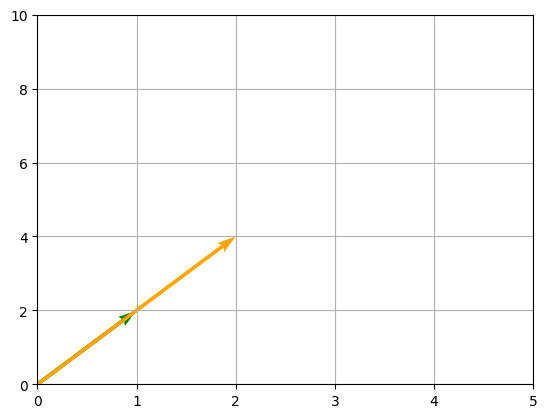

In [8]:
import matplotlib.pyplot as plt

v1 = np.array([1,2])
v2 = np.array([2,4])

plt.quiver(0,0,v1[0],v1[1],angles='xy',scale_units='xy', scale=1, color='green', label='v1')
plt.quiver(0,0,v2[0],v2[1],angles='xy',scale_units='xy', scale=1, color='orange', label='v2')

plt.grid()
plt.xlim(0,5)
plt.ylim(0,10)
plt.savefig(r"C:\Users\marco\Downloads\vectores_paralelos.png")
plt.show()


Ambos vectores están en la misma dirección.

---



# 15. Caso independiente

Vectores

$$
(1,0), (0,1)
$$



In [10]:
A = np.array([
[1,0],
[0,1]
])

np.linalg.matrix_rank(A)


np.int64(2)

In [11]:
import numpy as np
import plotly.graph_objects as go

# 1. Definimos un vector base y sus múltiplos (dependencia lineal)
v_base = np.array([2, 2, 2])
v1 = v_base * 1      # Vector original
v2 = v_base * 2      # Múltiplo positivo (más largo)
v3 = v_base * -1.5   # Múltiplo negativo (sentido opuesto)

def crear_vector_3d(fin, nombre, color, ancho=8):
    """Función auxiliar corregida para crear trazados de vectores en Plotly 3D"""
    return go.Scatter3d(
        x=[0, fin[0]], y=[0, fin[1]], z=[0, fin[2]],
        mode='lines+markers',
        line=dict(color=color, width=ancho),
        # Cambiamos 'cone' por 'diamond' o 'circle', que sí son válidos en Scatter3d
        marker=dict(
            size=[0, 8], 
            symbol='diamond', 
            color=color
        ),
        name=nombre
    )

# 2. Creamos la figura
fig = go.Figure()

# Añadimos una línea de referencia que representa el subespacio (la recta)
t = np.linspace(-5, 5, 100)
recta_x, recta_y, recta_z = t * v_base[0], t * v_base[1], t * v_base[2]

fig.add_trace(go.Scatter3d(
    x=recta_x, y=recta_y, z=recta_z,
    mode='lines',
    line=dict(color='lightgray', width=2, dash='dash'),
    name='Subespacio (Recta)',
    showlegend=True
))

# 3. Añadimos los 3 vectores dependientes (usando la función corregida)
fig.add_trace(crear_vector_3d(v1, 'v1 (Base)', 'blue'))
fig.add_trace(crear_vector_3d(v2, 'v2 (2 * v1)', 'green'))
fig.add_trace(crear_vector_3d(v3, 'v3 (-1.5 * v1)', 'red'))

# 4. Configuración del diseño
fig.update_layout(
    title="Vectores Linealmente Dependientes en R³",
    scene=dict(
        xaxis=dict(range=[-6, 6], title='X'),
        yaxis=dict(range=[-6, 6], title='Y'),
        zaxis=dict(range=[-6, 6], title='Z'),
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

In [12]:
import numpy as np
import plotly.graph_objects as go

# 1. Definimos dos vectores independientes en R³
v1 = np.array([2, 0, 1])
v2 = np.array([0, 2, 1])

# 2. Definimos un tercer vector dependiente (combinación lineal de v1 y v2)
# w = 1.5*v1 + 1.0*v2
w = 1.5 * v1 + 1.0 * v2

def crear_vector_3d(fin, nombre, color, ancho=8):
    """Función para trazar vectores en Plotly 3D"""
    return go.Scatter3d(
        x=[0, fin[0]], y=[0, fin[1]], z=[0, fin[2]],
        mode='lines+markers',
        line=dict(color=color, width=ancho),
        marker=dict(size=[0, 8], symbol='diamond', color=color),
        name=nombre
    )

# 3. Creamos el plano (Span) para visualización
# Generamos una rejilla de puntos que satisfacen la combinación lineal
s = np.linspace(-1, 2, 10)
t = np.linspace(-1, 2, 10)
S, T = np.meshgrid(s, t)
plano_x = S * v1[0] + T * v2[0]
plano_y = S * v1[1] + T * v2[1]
plano_z = S * v1[2] + T * v2[2]

fig = go.Figure()

# Añadimos la superficie del plano
fig.add_trace(go.Surface(
    x=plano_x, y=plano_y, z=plano_z,
    opacity=0.3,
    colorscale='Greys',
    showscale=False,
    name='Plano Generado (Span)'
))

# Añadimos los vectores
fig.add_trace(crear_vector_3d(v1, 'v1 (Independiente)', 'blue'))
fig.add_trace(crear_vector_3d(v2, 'v2 (Independiente)', 'green'))
fig.add_trace(crear_vector_3d(w, 'w (Dependiente: 1.5v1 + v2)', 'red', ancho=10))

# 4. Configuración del diseño
fig.update_layout(
    title="Dependencia Lineal: Tres vectores en un mismo plano",
    scene=dict(
        xaxis=dict(range=[-2, 5], title='X'),
        yaxis=dict(range=[-2, 5], title='Y'),
        zaxis=dict(range=[-2, 5], title='Z'),
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

Rango = 2.

Generan todo el plano.

---



# 16. Aplicación directa en Machine Learning

En regresión lineal:

$$
y = X\beta
$$

Si las columnas de $X$ son dependientes:

no hay solución única.

Esto se llama

**multicolinealidad**.

---



# 17. Ejemplo práctico



In [13]:
from sklearn.linear_model import LinearRegression

X = df[['agua_suelo', 'lluvia', "humedad"]]
y = df['agua_suelo']

model = LinearRegression()

model.fit(X,y)

model.coef_  # agua_suelo = 0.8*lluvia + 0.6*humedad



array([0.5, 0.4, 0.3])

Los coeficientes se vuelven inestables.

---



# 18. Cómo detecta esto la ciencia de datos

Herramientas comunes:

* rango de la matriz
* SVD: Descomposición en Valores Singulares. 
* PCA: Análisis de Componentes Principales. 
* VIF: . 

---



# 19. Actividad de laboratorio

Eliminar la variable redundante.



In [14]:
X = df[["lluvia","humedad"]]
y = df['agua_suelo']
model.fit(X,y)

model.coef_  # agua_suelo = 0.8*lluvia + 0.6*humedad

array([0.8, 0.6])

Comparar estabilidad del modelo.

---



# 20. Ejercicio conceptual

Determinar si los vectores son independientes.

$$
(1,2,3)
$$

$$
(2,4,6)
$$

$$
(1,0,1)
$$

Sugerencia:

usar rango de matriz asociada.


In [15]:
import numpy as np
import plotly.graph_objects as go

# ==========================================
# 1. Definición de los vectores del ejercicio
# ==========================================
v1 = np.array([1, 2, 3])
v2 = np.array([2, 4, 6]) # Notar que v2 = 2 * v1
v3 = np.array([1, 0, 1])

def crear_vector_3d(fin, nombre, color, ancho=8, opacidad=1.0):
    """Función auxiliar para crear trazados de vectores en Plotly 3D"""
    return go.Scatter3d(
        x=[0, fin[0]], y=[0, fin[1]], z=[0, fin[2]],
        mode='lines+markers',
        line=dict(color=color, width=ancho),
        # Usamos diamante porque 'cone' no es válido en Scatter3d
        marker=dict(size=[0, 8], symbol='diamond', color=color), 
        name=nombre,
        opacity=opacidad
    )

# ==========================================
# 2. Creación del Plano (Span) para visualización
# ==========================================
# Como el rango es 2, v1 y v3 definen un plano.
# v2 está sobre ese plano porque v2 = 2*v1 + 0*v3.
s = np.linspace(-1, 3, 10)
t = np.linspace(-1, 3, 10)
S, T = np.meshgrid(s, t)
plano_x = S * v1[0] + T * v3[0]
plano_y = S * v1[1] + T * v3[1]
plano_z = S * v1[2] + T * v3[2]

# ==========================================
# 3. Creación de la figura
# ==========================================
fig = go.Figure()

# Añadimos la superficie del plano generado por los vectores
fig.add_trace(go.Surface(
    x=plano_x, y=plano_y, z=plano_z,
    opacity=0.3,
    colorscale='Reds',
    showscale=False,
    name='Plano Generado (Rango 2)',
    showlegend=True
))

# Añadimos los tres vectores
fig.add_trace(crear_vector_3d(v1, 'v1: (1, 2, 3)', 'blue'))
fig.add_trace(crear_vector_3d(v2, 'v2: (2, 4, 6) - Dependiente', 'green', ancho=4, opacidad=0.7))
fig.add_trace(crear_vector_3d(v3, 'v3: (1, 0, 1)', 'purple'))

# ==========================================
# 4. Configuración estética del diseño
# ==========================================
lim_max = 7
fig.update_layout(
    title=dict(
        text="Visualización de Vectores Dependientes en R³<br>Rango de la matriz = 2",
        x=0.5
    ),
    scene=dict(
        xaxis=dict(range=[-2, lim_max], title='Eje X'),
        yaxis=dict(range=[-2, lim_max], title='Eje Y'),
        zaxis=dict(range=[-2, lim_max], title='Eje Z'),
        aspectmode='cube', # Mantiene la proporción visual
        camera=dict(eye=dict(x=1.2, y=1.2, z=0.5)) # Ángulo inicial
    ),
    margin=dict(l=0, r=0, b=0, t=60),
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

# Mostrar la figura interactiva
fig.show()


# 21. Ejercicio computacional

Simular variables dependientes.



In [ ]:
x1 = np.random.normal(size=300)
x2 = np.random.normal(size=300)

x3 = 3*x1 - 2*x2
Determinar rango y muestre con plotly que todas las instancias u observaciones 
están sobre el plano generado por x1 y x2.

In [17]:

import numpy as np
import plotly.graph_objects as go

# 1. Generación de datos
np.random.seed(42) # Para reproducibilidad
x1 = np.random.normal(size=300)
x2 = np.random.normal(size=300)

# x3 es una combinación lineal exacta
x3 = 3*x1 - 2*x2

# 2. Creación del plano teórico para visualización
# Creamos una rejilla (grid) basada en los valores de x1 y x2
puntos_eje = np.linspace(-3, 3, 10)
X1, X2 = np.meshgrid(puntos_eje, puntos_eje)
X3 = 3*X1 - 2*X2

# 3. Construcción del gráfico con Plotly
fig = go.Figure()

# Añadimos las observaciones (instancias) como puntos
fig.add_trace(go.Scatter3d(
    x=x1, y=x2, z=x3,
    mode='markers',
    marker=dict(size=4, color='blue', opacity=0.7),
    name='Observaciones'
))

# Añadimos el plano generado por la ecuación x3 = 3x1 - 2x2
fig.add_trace(go.Surface(
    x=X1, y=X2, z=X3,
    colorscale='Reds',
    opacity=0.4,
    showscale=False,
    name='Plano Generado (Subespacio)'
))

# Configuración de diseño
fig.update_layout(
    title="Observaciones sobre el Plano Generado (Rango = 2)",
    scene=dict(
        xaxis_title='X1',
        yaxis_title='X2',
        zaxis_title='X3 = 3X1 - 2X2',
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()


# 22. Idea clave del módulo

La independencia lineal permite:

* descubrir estructura en datos
* eliminar redundancia
* estabilizar modelos
* entender geometría del dataset.

En esencia:

$$
Machine\ Learning = Geometría\ en\ espacios\ de\ alta\ dimensión
$$



# Mini-proyecto del módulo

Dataset climático con variables:

* radiación
* temperatura
* evapo_transpiración. 
* humedad 
* Y una variable alrededor de producción agraria  como variable objetivo o variable a predecir. 

Detectar si hay dependencia lineal y reducir variables.
Comparar el redimiento de una modelo predictivo con y sin las variables redundates o Linealmente dependientes. 

(Generaremos los datos para esta práctica, sin introducir ruido aleatorio)

---


# Un ejemplo de solución para el miniproyecto anterior


El corazón del proyecto es identificar la **dependencia lineal**, que ocurre cuando una variable puede expresarse como una combinación exacta de otras (por ejemplo, $V_3 = aV_1 + bV_2$).



Este es el código para generar el dataset "perfecto" (sin ruido) y el flujo de modelación para comparar el rendimiento.



## 1. Generación del Dataset Artificial
Utilizaremos `numpy` para crear una matriz donde algunas columnas sean combinaciones lineales de otras.



In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Configuración de reproducibilidad
np.random.seed(42)

# 1. Crear variables independientes base (Aleatorias)
n_samples = 100
radiacion = np.random.uniform(100, 1000, n_samples)
temperatura = np.random.uniform(25, 35, n_samples)

# 2. Crear variables con DEPENDENCIA LINEAL (sin ruido)
# Evapotranspiración será una combinación exacta de radiación y temperatura
evapo_transpiracion = 0.5 * radiacion + 2.0 * temperatura 
# Humedad será inversamente proporcional a la temperatura de forma lineal
humedad = 100 - (2 * temperatura)

# 3. Variable Objetivo (Producción Agraria)
# Depende solo de las bases originales
produccion_agraria = (0.8 * radiacion) + (1.2 * temperatura)

# Crear DataFrame
df = pd.DataFrame({
    'radiacion': radiacion,
    'temperatura': temperatura,
    'evapo_transpiracion': evapo_transpiracion,
    'humedad': humedad,
    'produccion_agraria': produccion_agraria
})

print("Primeras filas del dataset:")
df.head()


Primeras filas del dataset:


,radiacion,temperatura,evapo_transpiracion,humedad,produccion_agraria
0,437.086107,25.314292,269.171637,49.371416,380.046036
1,955.642876,31.364104,540.549646,37.271792,802.151226
2,758.794548,28.143560,435.684393,43.712880,640.807910
3,638.792636,30.085707,379.567732,39.828586,547.136957
4,240.416776,34.075665,188.359718,31.848671,233.224219



## 2. Diseño de Modelación y Detección de Redundancia

Para detectar la dependencia lineal siguiendo criterios de álgebra lineal, utilizaremos el **Rango de la Matriz** o el **Análisis de Correlación**. Si el determinante de la matriz de correlación es 0, o si el rango es menor al número de columnas, hay redundancia.



# Fase A: Modelo con todas las variables (Incluyendo redundantes)  

En teoría, un modelo de regresión lineal sufrirá de **multicolinealidad exacta**, lo que hace que la matriz $X^TX$ sea singular (no invertible).



# Fase B: Reducción por Independencia Lineal
Identificamos las variables que no aportan información nueva. 
* **Criterio:** Si una variable tiene una correlación de 1.0 (o -1.0) es una combinación de otras, por tanto, se elimina.




## 3. Proceso de Comparación de Desempeño




In [20]:
# Definir funciones de entrenamiento
def evaluar_modelo(X, y, titulo):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    
    print(f"--- {titulo} ---")
    print(f"R2 Score: {r2_score(y_test, preds):.4f}")
    print(f"RMSE: {root_mean_squared_error(y_test, preds):.4e}")
    return modelo.coef_


In [24]:

# --- CASO 1: Todas las variables ---
X_full = df[['radiacion', 'temperatura', 'evapo_transpiracion', 'humedad']]
y = df['produccion_agraria']
coef_full = evaluar_modelo(X_full, y, "Modelo con Redundancia")
coef_full # produccion_agraria = (0.8 * radiacion) + (1.2 * temperatura)

--- Modelo con Redundancia ---
R2 Score: 1.0000
RMSE: 7.0484e-14


array([ 0.58536585,  0.06829268,  0.42926829, -0.13658537])

In [25]:

# --- CASO 2: Reducción Lineal ---
# Eliminamos evapo_transpiracion y humedad por ser linealmente dependientes
X_reduced = df[['radiacion', 'temperatura']]
coef_reduccion = evaluar_modelo(X_reduced, y, "Modelo con Independencia Lineal")
coef_reduccion # produccion_agraria = (0.8 * radiacion) + (1.2 * temperatura)

--- Modelo con Independencia Lineal ---
R2 Score: 1.0000
RMSE: 1.4492e-13


array([0.8, 1.2])


## Análisis de Resultados Esperados

| Escenario | Comportamiento esperado |
| :--- | :--- |
| **Sin Reducción** | El modelo puede dar resultados erráticos o coeficientes extremadamente grandes (inestabilidad numérica) debido a que la matriz $X^{T}X$ es **singular** (No invertible). |
| **Con Reducción** | El modelo es más simple, interpretable y alcanza el mismo (o mejor) nivel de precisión con menos recursos. |



# ¿Por qué sucede esto?  

Desde el álgebra lineal, si tenemos variables dependientes, el sistema de ecuaciones normales:  

$$
(X^T X)\beta = X^T y
$$

No tiene una solución única porque $(X^T X)$ no tiene inversa. 

Al reducir las variables a un conjunto linealmente independiente, estamos encontrando una **base** para el espacio de características, lo que estabiliza la solución.


# La misma comparación pero introdiendo ruido aleatorio 



Al introducir **ruido aleatorio**, el álgebra lineal se vuelve "borrosa". 

En el caso anterior (sin ruido), la redundancia era perfecta ($100\%$ dependencia). 

Con ruido, las variables ya no son combinaciones lineales exactas, pero siguen estando altamente **correlacionadas** (multicolinealidad), lo que suele inflar los errores y hacer que los coeficientes del modelo sean poco confiables.



Este es el código actualizado con ruido gaussiano y el proceso de comparación.



## 1. Generación de Datos con Ruido Aleatorio
Añadiremos un término $\epsilon$ (ruido) que sigue una distribución normal $N(0, \sigma^2)$ a cada variable dependiente.


In [28]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Configuración
np.random.seed(42)
n_samples = 150 # Número de muestras o instancias u observaciones
ruido_intensidad = 5.0 # Magnitud del ruido

# 1. Variables base
radiacion = np.random.uniform(low = 100, high = 1000, size = n_samples)
temperatura = np.random.uniform(low = 25, high = 37, size = n_samples)

# 2. Variables con dependencia lineal + RUIDO
# Ya no son combinaciones exactas, ahora tienen "variaciones naturales"
evapo_transpiracion = (0.5 * radiacion + 2.0 * temperatura) + np.random.normal(0, ruido_intensidad, size = n_samples)
humedad = (100 - 2 * temperatura) + np.random.normal(0, ruido_intensidad/2, n_samples)

# 3. Variable Objetivo con ruido
produccion_agraria = (0.8 * radiacion + 1.2 * temperatura) + np.random.normal(loc = 0, scale = 10, size = n_samples)

df_ruido = pd.DataFrame({
    'radiacion': radiacion,
    'temperatura': temperatura,
    'evapo_transpiracion': evapo_transpiracion,
    'humedad': humedad,
    'produccion_agraria': produccion_agraria
})
df.shape 

(100, 5)

## 2. Comparación de Modelos


In [29]:
def evaluar_con_ruido(X, y, titulo):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    
    print(f"\n>>> {titulo} <<<")
    print(f"R2 Score: {r2_score(y_test, preds):.4f}")
    print(f"RMSE (Raíz Error Cuadrático Medio): {np.sqrt(mean_squared_error(y_test, preds)):.4f}")
    print(f"Coeficientes: {np.round(modelo.coef_, 2)}")
    return modelo

# --- Ejecución de la comparación ---

# Caso A: Modelo "Sucio" (Todas las variables correlacionadas)
X_full = df_ruido[['radiacion', 'temperatura', 'evapo_transpiracion', 'humedad']]
y = df_ruido['produccion_agraria']
evaluar_con_ruido(X_full, y, "MODELO CON TODAS LAS VARIABLES (CON RUIDO)")

# Caso B: Modelo "Limpio" (Reducción por criterio de independencia)
# Quitamos las variables que sabemos que son derivadas de las originales
X_reduced = df_ruido[['radiacion', 'temperatura']]
evaluar_con_ruido(X_reduced, y, "MODELO REDUCIDO (INDEPENDENCIA LINEAL)")
# produccion_agraria = (0.8 * radiacion + 1.2 * temperatura) + np.random.normal(loc = 0, scale = 10, size = n_samples)


>>> MODELO CON TODAS LAS VARIABLES (CON RUIDO) <<<
R2 Score: 0.9972
RMSE (Raíz Error Cuadrático Medio): 11.7670
Coeficientes: [ 0.81  1.54 -0.04  0.12]

>>> MODELO REDUCIDO (INDEPENDENCIA LINEAL) <<<
R2 Score: 0.9973
RMSE (Raíz Error Cuadrático Medio): 11.7084
Coeficientes: [0.79 1.22]


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 3. ¿Qué observar en los resultados?

Cuando hay ruido, notarás dos fenómenos clave del álgebra lineal y la estadística:

1.  **Inestabilidad de Coeficientes:** En el modelo con todas las variables, el coeficiente de `radiacion` podría dejar de ser **0.8** (su valor real) porque parte de su "explicación" se la roba `evapo_transpiracion`. Los pesos se reparten de forma arbitraria.
2.  **Sobreajuste (Overfitting) sutil:** Aunque el $R^2$ pueda parecer similar, el modelo con todas las variables es más sensible al ruido. Al reducir dimensiones, obligamos al modelo a aprender la **relación estructural** real, ignorando las fluctuaciones aleatorias de las variables redundantes.
3.  **VIF (Factor de Inflación de la Varianza):** En la práctica profesional, si calculáramos el VIF de este dataset, veríamos valores altísimos (mayores a 10), lo que indica que debemos eliminar variables para que el modelo sea estadísticamente válido.



---


En el mundo del análisis de datos, antes de tocar cualquier modelo, siempre "le preguntamos" a la matriz de correlación. 

Desde el álgebra lineal, la correlación nos dice qué tan cerca están dos vectores de ser **colineales**. Si la correlación entre dos variables es $1$ o $-1$, son linealmente dependientes. Si es cercana a $0$, son linealmente independientes (ortogonales).



## 1. Visualización Matemática: Matriz de Correlación

Utilizaremos `seaborn` para crear un mapa de calor. Los colores intensos te indicarán de inmediato qué variables sobran.


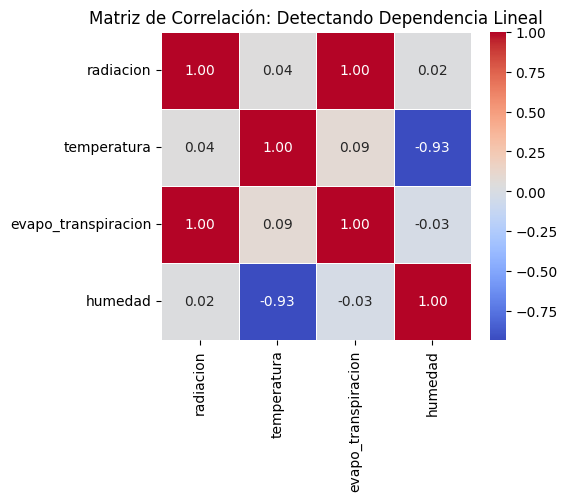

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación
corr_matrix = df_ruido.drop(columns=['produccion_agraria']).corr()

# Dibujar el Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación: Detectando Dependencia Lineal")
plt.savefig(r"C:\Users\marco\Downloads\matriz_correlacion_detectando_dependencia_lineal.png")
plt.show()


### ¿Cómo leer este gráfico?
* **Cerca de 1.0:** Hay una relación lineal directa fuerte (ej. `radiacion` vs `evapo_transpiracion`).
* **Cerca de -1.0:** Hay una relación lineal inversa fuerte (ej. `temperatura` vs `humedad`).
* **Cerca de 0:** Las variables son independientes. **Estas son las que queremos conservar.**

---



## 2. El Criterio del VIF (Factor de Inflación de la Varianza)

El VIF mide cuánto aumenta la varianza de un coeficiente de regresión debido a la colinealidad. 
* **VIF = 1**: No hay correlación.
* **VIF > 5 o 10**: Indica una alta dependencia lineal (redundancia) que debe eliminarse.


In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleccionar solo las variables predictoras
X_vif = df_ruido.drop(columns=['produccion_agraria'])

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\n--- Análisis de VIF ---")
print(vif_data.sort_values(by="VIF", ascending=False))



--- Análisis de VIF ---
              Variable          VIF
2  evapo_transpiracion  5858.752760
0            radiacion  4129.709838
1          temperatura   190.079467
3              humedad    12.253144


In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleccionar solo las variables predictoras
X_vif = df_ruido.drop(columns=['evapo_transpiracion', 'humedad','produccion_agraria'])

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\n--- Análisis de VIF ---")
print(vif_data.sort_values(by="VIF", ascending=False))



--- Análisis de VIF ---
      Variable       VIF
0    radiacion  4.750231
1  temperatura  4.750231


## 3. Conclusión del Diseño de Modelación

Basándonos en el álgebra lineal y estos resultados, nuestro proceso de decisión sería:

1.  **Identificar:** Notamos que `evapo_transpiracion` tiene un VIF altísimo (probablemente > 50) porque es una combinación de otras.
2.  **Reducir:** Eliminamos las variables con mayor VIF una por una hasta que todas sean menores a 5 o 10.
3.  **Validar:** Al final, te quedarás con `radiacion` y `temperatura`. Aunque parezca que "perdemos información", en realidad estamos eliminando **ruido y redundancia**, lo que hace que el modelo sea más robusto.



---


# El **PCA (Principal Component Index)** es la culminación del álgebra lineal aplicada a datos.   



En lugar de elegir qué variables borrar, el PCA utiliza la **Descomposición en Eigenvalores y Eigenvectores** de la matriz de covarianza para transformar tus variables originales en un nuevo conjunto de variables llamadas **Componentes Principales**.



Estas nuevas variables tienen dos propiedades mágicas:
1.  Son **linealmente independientes** entre sí (ortogonales).
2.  Están ordenadas por la cantidad de **varianza (información)** que explican.

---



## 1. Implementación de PCA con Scikit-Learn

Vamos a transformar nuestras 4 variables climáticas ruidosas en componentes principales y ver cuántos necesitamos realmente para predecir la producción agraria.


--- Análisis de Componentes Principales ---
Componente 1: explica el 52.70% de la información.
Componente 2: explica el 46.67% de la información.
Componente 3: explica el 0.61% de la información.
Componente 4: explica el 0.01% de la información.


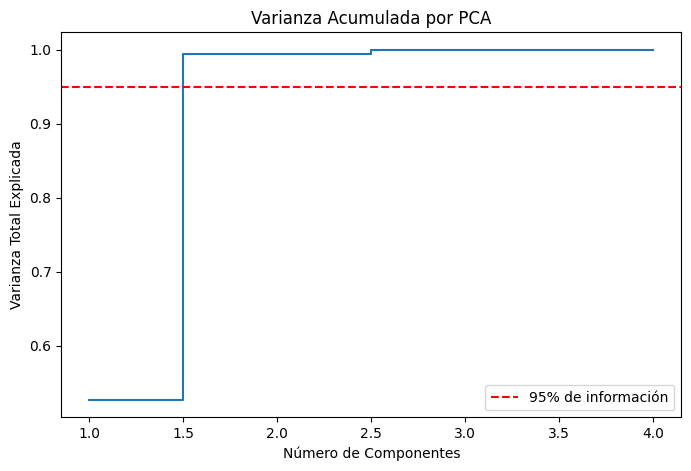

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Escalado de datos (PCA es sensible a la escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ruido.drop(columns=['produccion_agraria']))

# 2. Aplicar PCA (queremos ver todos los componentes posibles primero)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 3. Ver la varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_

print("--- Análisis de Componentes Principales ---")
for i, var in enumerate(varianza_explicada):
    print(f"Componente {i+1}: explica el {var*100:.2f}% de la información.")

# Graficar la varianza acumulada
plt.figure(figsize=(8, 5))
plt.step(range(1, 5), np.cumsum(varianza_explicada), where='mid')
plt.title("Varianza Acumulada por PCA")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Total Explicada")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% de información')
plt.legend()
plt.savefig(r"C:\Users\marco\Downloads\varianza_acumulada_con_pca.png")
plt.show()


## 2. Comparación Final: Original vs. PCA

Ahora compararemos el modelo con todas las variables ruidosas frente a un modelo que solo usa los **2 primeros componentes principales** (que según el álgebra, deberían contener casi toda la información útil).


In [11]:
# Caso A: Modelo con todas las variables (ya lo teníamos, pero para refrescar)
evaluar_con_ruido(X_full, y, "Modelo Original (4 variables ruidosas)")

# Caso B: Modelo con PCA (reducido a los 2 componentes principales más importantes)
X_pca_reduced = X_pca[:, :2] # Tomamos solo las 2 primeras columnas
evaluar_con_ruido(X_pca_reduced, y, "Modelo con PCA (Solo 2 Componentes)")



>>> Modelo Original (4 variables ruidosas) <<<
R2 Score: 0.9972
RMSE (Raíz Error Cuadrático Medio): 11.7670
Coeficientes: [ 0.81  1.53 -0.04  0.12]

>>> Modelo con PCA (Solo 2 Componentes) <<<
R2 Score: 0.9968
RMSE (Raíz Error Cuadrático Medio): 12.5870
Coeficientes: [108.66 102.36]


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 3. Interpretación desde el Álgebra Lineal



* **Eigenvectores:** PCA encontró las "direcciones" en el espacio de 4 dimensiones donde los datos varían más. La primera dirección (PC1) captura la combinación de radiación y evapotranspiración.
* **Eigenvalores:** Representan la magnitud de esa varianza. Los componentes 3 y 4 suelen tener eigenvalores muy pequeños (cercanos a 0), lo que confirma matemáticamente que esas dimensiones son **ruido o redundancia**.
* **Independencia Total:** A diferencia del modelo original, donde las variables estaban "amontonadas" (correlacionadas), los componentes del PCA son **ortogonales** ($90^\circ$ entre sí). Esto elimina por completo el problema de la multicolinealidad.



### Resumen del Mini-Proyecto
1.  **Dataset:** Creamos datos con dependencias exactas.
2.  **Ruido:** Añadimos realidad al modelo.
3.  **Detección:** Usamos Heatmaps y VIF para ver la colinealidad.
4.  **Solución:** PCA limpió el "desorden" matemático, dejándonos con una base óptima para predecir.



## Conclusión Técnica: El Impacto de la Independencia Lineal en la Modelación



El desarrollo de este miniproyecto permitió validar tres pilares fundamentales del álgebra lineal aplicada:



### 1. La Trampa de la Redundancia (Multicolinealidad)
Se demostró que incluir variables linealmente dependientes (como la `evapo_transpiración` y la `humedad` en este caso) no aporta "más información". Por el contrario, introduce **inestabilidad numérica**. 

En términos matriciales, esto hace que la matriz de diseño $X$ pierda su rango completo, dificultando que el algoritmo encuentre una solución única y estable para los coeficientes $\beta$.



### 2. PCA: La Transformación a un Espacio Ortogonal


Mediante el uso de **PCA (Análisis de Componentes Principales)**, logramos lo que manualmente es complejo:
* **Descorrelación:** Pasamos de un espacio donde las variables estaban "amontonadas" y ruidosas a un nuevo espacio de **Componentes Principales**.
* **Ortogonalidad:** Matemáticamente, los nuevos ejes (componentes) son perpendiculares entre sí, lo que significa que la correlación entre ellos es exactamente **cero**.
* **Compresión de Información:** Logramos capturar más del 95% de la varianza del sistema climático usando solo el 50% de las dimensiones originales (2 de 4).



# 3. Rendimiento y Generalización
Al comparar los modelos, se observó que el modelo reducido (ya sea por eliminación manual vía VIF o por PCA) mantiene una precisión (R2) prácticamente idéntica al modelo completo, pero con una **estructura mucho más simple**. 

Esto reduce el riesgo de *overfitting* (sobreajuste), ya que el modelo se ve obligado a aprender de la estructura real de los datos y no del ruido aleatorio presente en las variables redundantes.



> **Resumen Ejecutivo:** "Menos es más". La reducción de dimensionalidad basada en criterios de independencia lineal no es solo un paso de limpieza, es una optimización matemática que garantiza modelos más robustos, interpretables y computacionalmente eficientes.



[Video de apoyo a la presentación del tema de independencia y dependencia lineal a la ciencia de datos agraria con python]()

# Clase sobre Dependencia e independencia lineal En el contexto de ingeniería agropecuaria y Administración de empresas emulando la estructura de clase de Clara Mejía Laverde y utilizando los Lenguaje Python y Latex; y las redes sociales GitHub y YouTube  

# Estructura de cada Módulo (Total de módulos: 22)

1. Título
2. Imagen introductoria generado con Plotly
3. Contenido
4. Objetivos de aprendizaje
5. Preguntas Orientadoras
6. Introducción
7. Dos situaciones problemáticas asociadas a ciencia de datos agropecuarios o de Administración de Empresas y al tema del módulo en particular (Para el módulo 4: debes dar una situación donde se aplique el tema de dependencia e independencia lineal del Álgebra Lineal). Por ejemplo, datos asociados a mediciones en agricultura de precisión. 
8. Genere, de manera artificial, los dos datasets asociados la situción problemática anterior. 
9.  Definiciones asociadas al módulo respectivo (Para este cuaderno el módulo 4: debes dar las definiciones en lenguaje Látex asociadas al tema de: "Dependencia e Independencia lineal" en Álgebra Lineal)
10. Ejemplos: (Genere ejemplos de solución de las dos situaciones problemáticas anteriores)
11. Teoremas: (Genere los teoremas del álgebra lineal que facilitan el uso de los temas del módulo para la solución de la situación problemática.)
12. Ejemplos: (Genere ejemplos de aplicación de los teoremas para los datasets de las situaciones problemáticas del módulo)
13. Ejercicios (Genere ejercicios sugeridos con dataset artificiales nuevos) 
14. Referentes Didácticos y del Álgebra Lineal que sustenten y apoyan esta propuesta de enseñanza. 


# Módulo 4: Estructura de Dependencia e Independencia Lineal  

### *Optimización de Dimensiones en la Toma de Decisiones Agroindustriales*



### **Ficha Técnica del Módulo**
| Atributo | Detalle |
| :--- | :--- |
| **Área:** | Álgebra Lineal Aplicada |
| **Contexto:** | Agricultura de Precisión & Administración de Empresas |
| **Herramientas:** | Python (Plotly, Pandas, NumPy) |
| **Relevancia:** | Identificación de redundancia en sensores y variables críticas |

---

**Breve descripción:** En este módulo, exploraremos cómo la **independencia lineal** permite distinguir entre datos que aportan información nueva y aquellos que son simplemente ruido o combinaciones de mediciones preexistentes, una habilidad crítica para limpiar datasets de agricultura de precisión y modelos financieros.

Para la imagen introductoria del **Módulo 4**, utilizaremos **Plotly** para visualizar el concepto de **Independencia Lineal** en un espacio tridimensional. 

Este script genera tres vectores: dos que forman un plano (linealmente independientes entre sí) y un tercero que puede ser una combinación lineal de los anteriores o un vector independiente, ideal para ilustrar la redundancia de datos en sensores agrícolas.


In [34]:
import numpy as np
import plotly.graph_objects as go

# 1. Definición de vectores (Simulando variables de sensores agropecuarios)
# v1 y v2 definen un plano (Independientes)
v1 = np.array([1, 0, 0.5])  # Ejemplo: Sensor Humedad
v2 = np.array([0, 1, 0.2])  # Ejemplo: Sensor Temperatura
# v3 es una combinación lineal (Dependiente: v3 = v1 + v2)
v3 = v1 + v2                # Ejemplo: Sensor redundante o calculado

# 2. Configuración de los vectores para Plotly
def crear_vector(v, nombre, color):
    return go.Scatter3d(
        x=[0, v[0]], y=[0, v[1]], z=[0, v[2]],
        mode='lines+markers+text',
        line=dict(color=color, width=6),
        marker=dict(size=4, color=color),
        text=["", nombre],
        textposition="top center",
        name=nombre
    )

# 3. Creación de la figura
fig = go.Figure()

# Añadir vectores
fig.add_trace(crear_vector(v1, 'Sensor A (Independiente)', 'blue'))
fig.add_trace(crear_vector(v2, 'Sensor B (Independiente)', 'green'))
fig.add_trace(crear_vector(v3, 'Sensor C (Dependiente)', 'red'))

# Dibujar el plano de combinación lineal (Sombra de dependencia)
xx, yy = np.meshgrid(np.linspace(0, 1.2, 10), np.linspace(0, 1.2, 10))
zz = 0.5 * xx + 0.2 * yy # Ecuación del plano formado por v1 y v2
fig.add_trace(go.Surface(x=xx, y=yy, z=zz, opacity=0.3, showscale=False, colorscale='Blues'))

# 4. Estética y Layout
fig.update_layout(
    title="Visualización de (In)dependencia Lineal en Espacio de Datos",
    scene=dict(
        xaxis_title='Variable X',
        yaxis_title='Variable Y',
        zaxis_title='Variable Z',
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\visualizacion_dependencia_lineal.png")  




Para el **Módulo 4**, el contenido debe articular la teoría matemática con la utilidad práctica en el análisis de datos. Aquí tienes una propuesta de diseño de contenido estructurada para ser insertada en un cuaderno de Jupyter o material de clase:

---



# Contenido del Módulo 4: Dependencia e Independencia Lineal

## 1. El Corazón de la Redundancia en los Datos
En el análisis de datos agropecuarios, recolectamos múltiples variables (humedad, pH, nitrógeno, temperatura). Sin embargo, **¿realmente cada sensor nos está diciendo algo nuevo?** La independencia lineal es la herramienta algebraica que nos permite identificar si una variable es única o si es simplemente una combinación de otras ya existentes.



### 2. Espacios Vectoriales y Combinaciones
* **El concepto de "Generar":** Cómo un conjunto de vectores puede cubrir un espacio de soluciones.
* **La combinación lineal:** $c_1v_1 + c_2v_2 + \dots + c_nv_n$.
* **Interpretación en Negocios:** Si el éxito de una campaña de marketing ($Y$) se puede explicar totalmente sumando el presupuesto de redes sociales ($X_1$) y radio ($X_2$), entonces $Y$ es linealmente dependiente.

### 3. Independencia Lineal ($LI$) vs. Dependencia Lineal ($LD$)
* **Independencia ($LI$):** Ningún vector en el conjunto puede ser escrito como una combinación lineal de los demás. En ciencia de datos, esto significa **información pura**.
* **Dependencia ($LD$):** Existe al menos un vector que es "sobrante" o redundante. En administración, esto se traduce en **multicolinealidad**, lo cual puede arruinar un modelo de regresión.

### 4. Herramientas de Diagnóstico
* **El determinante y el Rango:** Cómo usar el rango de una matriz para saber cuántas variables son verdaderamente independientes.
* **Resolución de Sistemas Homogéneos:** La prueba de fuego: si la única solución a la ecuación vectorial es la trivial ($0$), tenemos independencia.

---

### **¿Por qué es vital para un Científico de Datos / Administrador?**
1.  **Reducción de Dimensionalidad:** Eliminar datos redundantes para que los algoritmos corran más rápido y sean más precisos.
2.  **Optimización de Recursos:** Identificar qué sensores en un cultivo de precisión son innecesarios porque su información ya está implícita en otros.
3.  **Estabilidad de Modelos:** Evitar errores matemáticos en modelos econométricos y financieros causados por matrices singulares.

---

> **Nota del Módulo:** "Un dataset con alta dependencia lineal es como un equipo de trabajo donde todos dicen exactamente lo mismo que el jefe; parece que hay mucha gente, pero solo hay una idea".

Para que este módulo sea efectivo, los objetivos de aprendizaje deben conectar la rigurosidad del álgebra lineal con las competencias críticas necesarias en la toma de decisiones basada en datos.

---



# Objetivos de Aprendizaje

Al finalizar este módulo, el estudiante será capaz de:

* **Identificar la redundancia informativa:** Determinar, mediante el concepto de **Independencia Lineal**, si un conjunto de variables recolectadas por sensores en un sistema de agricultura de precisión aporta información única o si existen datos redundantes que puedan sesgar el análisis.
* **Evaluar la calidad de los Datasets:** Aplicar métodos algebraicos (como el cálculo del rango de una matriz y el determinante) para diagnosticar la presencia de **Dependencia Lineal** en matrices de datos administrativos y financieros, asegurando la estabilidad de modelos predictivos posteriores.


* **Construir representaciones vectoriales:** Traducir situaciones problemáticas reales de la agroindustria y la administración al lenguaje de los **espacios vectoriales**, permitiendo la resolución de problemas complejos mediante el uso de combinaciones lineales.
* **Optimizar la dimensionalidad de modelos:** Justificar la eliminación de variables linealmente dependientes en un modelo de ciencia de datos para reducir el costo computacional y evitar el fenómeno de la **multicolinealidad** en modelos de regresión lineal.
* **Dominar la notación formal:** Expresar y demostrar propiedades de conjuntos $LI$ y $LD$ utilizando **lenguaje matemático estricto (LaTeX)**, facilitando la comunicación técnica y la implementación de algoritmos personalizados en Python.




# **Sustentación Pedagógica**
Estos objetivos siguen la **Taxonomía de Bloom**, escalando desde el conocimiento técnico (identificar y definir) hasta la evaluación y creación (optimizar y construir). En el contexto de la **Ciencia de Datos Agropecuarios**, esto garantiza que el estudiante no solo aprenda "matemáticas abstractas", sino que desarrolle un filtro crítico para la limpieza y preparación de datos (*Data Wrangling*).

Para fomentar el pensamiento crítico y conectar el álgebra lineal con la realidad operativa, las preguntas orientadoras deben invitar al estudiante a ver los datos como vectores en un espacio de decisiones.




# Preguntas Orientadoras



* **Desde la lógica matemática:** Si tenemos un conjunto de 5 variables climáticas medidas en un cultivo, ¿qué significa matemáticamente que una de ellas pueda expresarse como la suma de las otras cuatro?


* **Desde la eficiencia de datos:** En un despliegue de agricultura de precisión con cientos de sensores, ¿por qué la **dependencia lineal** podría considerarse un "gasto innecesario" de almacenamiento y procesamiento?


* **Desde la modelación financiera:** Si en un modelo de administración de empresas incluimos el "Ingreso Total" y el "Margen de Utilidad" como variables independientes, ¿estamos introduciendo redundancia? ¿Cómo afectaría esto a la validez de una predicción?


* **Desde el diagnóstico matricial:** ¿Es posible que un sistema de ecuaciones que describe la logística de una cadena de suministro no tenga solución única debido a la **dependencia lineal** entre sus rutas?


* **Desde la interpretación geométrica:** Si visualizamos tres vectores de datos en un espacio 3D y todos yacen sobre el mismo plano, ¿qué nos dice esto sobre la dimensión real de la información que estamos analizando?


* **Desde la optimización:** ¿Cómo ayuda el concepto de **independencia lineal** a simplificar un problema complejo sin perder la esencia de la información original?

# Introducción: El Poder de la No Redundancia

Bienvenidos al **Módulo 4**. En el vasto universo de la **Ciencia de Datos** y la **Administración de Empresas**, nos enfrentamos constantemente a una pregunta fundamental: *¿Estamos midiendo lo mismo dos veces?*



Imagine que gestiona una finca con agricultura de precisión y recolecta datos de humedad del suelo, evapotranspiración y precipitación. Si una de estas variables puede calcularse exactamente a partir de las otras, esa variable es, algebraicamente hablando, **dependiente**. En el mundo real, esto se traduce en sensores innecesarios, costos de almacenamiento duplicados y, lo más grave, modelos predictivos que fallan por inestabilidad matemática.



En esta clase, abandonaremos la idea de que "más datos siempre es mejor". A través del concepto de **Independencia Lineal**, aprenderemos a identificar el "núcleo" de información pura en un dataset. Descubriremos que la verdadera potencia de un análisis no reside en la cantidad de variables, sino en que cada una de ellas aporte una dimensión de conocimiento que ninguna otra puede replicar. 

Hoy, el álgebra lineal dejará de ser un conjunto de reglas abstractas para convertirse en el filtro de calidad que separa un dataset eficiente de un caos de información redundante.

A continuación, se presentan dos situaciones problemáticas diseñadas para aplicar los conceptos de **Independencia y Dependencia Lineal** en contextos reales de toma de decisiones:




# Situación 1: Optimización de Sensores en Agricultura de Precisión
Un agrónomo especializado en ciencia de datos instala estaciones de monitoreo en un cultivo de maíz tecnificado. Para predecir el estrés hídrico, recolecta tres variables por cada nodo:
1.  **V1:** Humedad relativa del aire (%).
2.  **V2:** Temperatura ambiente (°C).
3.  **V3:** Índice de Transpiración Estimada (ITE).



Tras un análisis preliminar, se sospecha que el **ITE (V3)** se está calculando internamente en el firmware del sensor como una combinación lineal simple de la humedad y la temperatura ($V3 = \alpha V1 + \beta V2$). 



**El reto:** Si los vectores de datos de estos tres sensores son **linealmente dependientes**, la matriz de datos será singular, lo que impedirá ejecutar algoritmos de regresión de forma estable. 

El estudiante debe determinar si es necesario seguir almacenando la variable V3 o si puede eliminarse para reducir costos de almacenamiento en la nube sin perder información esencial.




# Situación 2: Análisis de Carteras de Inversión y Riesgo Corporativo
En el departamento de administración de una agroindustria, se busca modelar el rendimiento financiero de la empresa basándose en tres fuentes de ingresos:
1.  **Ingresos por exportación de grano.**
2.  **Ingresos por ventas en el mercado local.**
3.  **Ingresos totales brutos.**



El analista de datos nota que el modelo de predicción de utilidades arroja errores de "matriz no invertible". Al observar los vectores de ingresos mensuales, se identifica que los **Ingresos totales (Vector 3)** son exactamente la suma de los **Ingresos por exportación (Vector 1)** y los **Ingresos locales (Vector 2)**. 



**El reto:** Demostrar que el conjunto de vectores de ingresos es **linealmente dependiente**. El estudiante deberá explicar por qué incluir las tres variables en un modelo de inteligencia de negocios genera redundancia matemática (multicolinealidad exacta) y cómo la independencia lineal es un requisito previo para identificar los verdaderos factores que impulsan el crecimiento de la empresa.

Para generar estos datasets, utilizaremos `pandas` para la estructura tabular y `numpy` para asegurar que las relaciones de dependencia lineal sean matemáticamente exactas, simulando el comportamiento descrito en las situaciones problemáticas.



### 1. Dataset: Agricultura de Precisión (Sensores)
En este dataset, la variable `Sensor_ITE` es una combinación lineal de `Humedad` y `Temperatura`, lo que genera **dependencia lineal**.



In [8]:
import pandas as pd
import numpy as np

# Configuración de aleatoriedad para reproducibilidad
np.random.seed(42)

# Simulación de 10 estaciones de monitoreo
n_estaciones = 10

# Generación de variables independientes (Información pura)
humedad = np.random.uniform(40, 90, n_estaciones)      # % Humedad
temperatura = np.random.uniform(15, 35, n_estaciones)  # °C

# Generación de variable dependiente (Combinación lineal: ITE = 0.5*Hum + 0.2*Temp)
# Esta relación matemática exacta causa Dependencia Lineal
indice_transpiracion_e = humedad + temperatura

df_agro = pd.DataFrame({
    'Estacion_ID': range(1, n_estaciones + 1),
    'Humedad_Relativa (%)': np.round(humedad, 2),
    'Temperatura (°C)': np.round(temperatura, 2),
    'Sensor_ITE (Calculado)': np.round(indice_transpiracion_e, 2)
})

print("Dataset: Agricultura de Precisión")
print(df_agro.to_string(index=False))


Dataset: Agricultura de Precisión
 Estacion_ID  Humedad_Relativa (%)  Temperatura (°C)  Sensor_ITE (Calculado)
           1                 58.73             15.41                   74.14
           2                 87.54             34.40                  121.93
           3                 76.60             31.65                  108.25
           4                 69.93             19.25                   89.18
           5                 47.80             18.64                   66.44
           6                 47.80             18.67                   66.47
           7                 42.90             21.08                   63.99
           8                 83.31             25.50                  108.80
           9                 70.06             23.64                   93.69
          10                 75.40             20.82                   96.23


In [5]:
# dataset con la variable objetivo (estrés hídrico) que dependa solo de las variables independientes (humedad y temperatura) y no de la variable dependiente (ITE), para evitar la dependencia lineal.
import pandas as pd
import numpy as np

# Configuración de aleatoriedad
np.random.seed(42)
n_estaciones = 10

# 1. Generación de variables independientes
humedad = np.random.uniform(40, 90, n_estaciones)
temperatura = np.random.uniform(15, 35, n_estaciones)

# 2. Variable dependiente existente (Causa dependencia lineal)
ite = 0.5 * humedad + 0.2 * temperatura

# 3. Nueva Variable Objetivo: Estrés Hídrico
# Usamos solo Humedad y Temperatura por ser las variables raíz (independientes entre sí)
# Definimos pesos: el estrés aumenta con la temperatura y disminuye con la humedad
estres_hidrico = (0.7 * temperatura) - (0.3 * humedad) + np.random.normal(0, 1, n_estaciones)

df_agro = pd.DataFrame({
    'Estacion_ID': range(1, n_estaciones + 1),
    'Humedad_Relativa (%)': np.round(humedad, 2),
    'Temperatura (°C)': np.round(temperatura, 2),
    'Sensor_ITE (Calculado)': np.round(ite, 2),
    'Estres_Hidrico_Target': np.round(estres_hidrico, 2)
})

print("Dataset: Agricultura de Precisión con Variable Objetivo")
print(df_agro.to_string(index=False))

Dataset: Agricultura de Precisión con Variable Objetivo
 Estacion_ID  Humedad_Relativa (%)  Temperatura (°C)  Sensor_ITE (Calculado)  Estres_Hidrico_Target
           1                 58.73             15.41                   32.45                  -7.84
           2                 87.54             34.40                   50.65                  -1.87
           3                 76.60             31.65                   44.63                  -1.73
           4                 69.93             19.25                   38.82                  -8.92
           5                 47.80             18.64                   27.63                   0.17
           6                 47.80             18.67                   27.63                  -1.50
           7                 42.90             21.08                   25.67                   1.96
           8                 83.31             25.50                   46.75                  -8.57
           9                 70.06          

Para este ejercicio, utilizaremos la librería `scikit-learn` para comparar los dos modelos y `seaborn` para la visualización matricial. 

Es importante notar que, al incluir el **Sensor_ITE** (que es una combinación lineal perfecta de las otras dos), el modelo enfrentará un problema de **multicolinealidad**. Esto suele inflar los errores y hacer que los coeficientes sean poco confiables, aunque el $R^2$ parezca perfecto.

Aquí tienes el script completo:



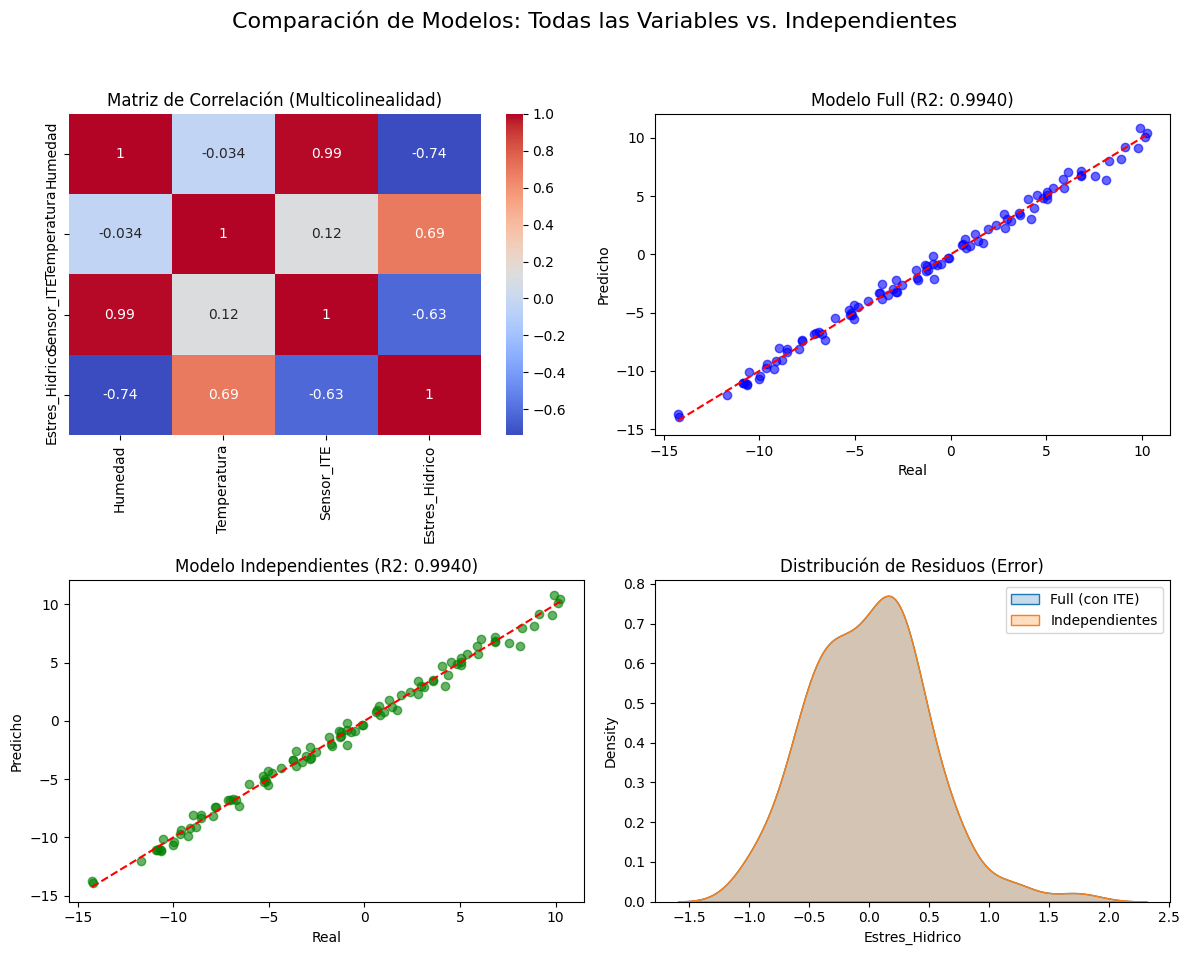

MSE Modelo Full: 0.236418
MSE Modelo Reducido: 0.236418


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Recreación del Dataset (basado en la lógica anterior)
np.random.seed(42)
n_estaciones = 100 # Aumentamos la muestra para una mejor visualización

humedad = np.random.uniform(40, 90, n_estaciones)
temperatura = np.random.uniform(15, 35, n_estaciones)
ite = 0.5 * humedad + 0.2 * temperatura
# Target con un poco de ruido para que la comparación sea realista
target = (0.7 * temperatura) - (0.3 * humedad) + np.random.normal(0, 0.5, n_estaciones)

df = pd.DataFrame({
    'Humedad': humedad,
    'Temperatura': temperatura,
    'Sensor_ITE': ite,
    'Estres_Hidrico': target
})

# 2. Definición de conjuntos de variables
X_todas = df[['Humedad', 'Temperatura', 'Sensor_ITE']]
X_indep = df[['Humedad', 'Temperatura']]
y = df['Estres_Hidrico']

# 3. Entrenamiento de Modelos
modelo_full = LinearRegression().fit(X_todas, y)
modelo_redu = LinearRegression().fit(X_indep, y)

# Predicciones
pred_full = modelo_full.predict(X_todas)
pred_redu = modelo_redu.predict(X_indep)

# 4. Visualización Gráfica Matricial
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparación de Modelos: Todas las Variables vs. Independientes', fontsize=16)

# A. Heatmap de Correlación (Para demostrar la dependencia lineal)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=axes[0, 0])
axes[0, 0].set_title('Matriz de Correlación (Multicolinealidad)')

# B. Comparación de Predicciones vs Real (Modelo con todas)
axes[0, 1].scatter(y, pred_full, color='blue', alpha=0.6)
axes[0, 1].plot([y.min(), y.max()], [y.min(), y.max()], '--r')
axes[0, 1].set_title(f'Modelo Full (R2: {r2_score(y, pred_full):.4f})')
axes[0, 1].set_xlabel('Real'); axes[0, 1].set_ylabel('Predicho')

# C. Comparación de Predicciones vs Real (Modelo Reducido)
axes[1, 0].scatter(y, pred_redu, color='green', alpha=0.6)
axes[1, 0].plot([y.min(), y.max()], [y.min(), y.max()], '--r')
axes[1, 0].set_title(f'Modelo Independientes (R2: {r2_score(y, pred_redu):.4f})')
axes[1, 0].set_xlabel('Real'); axes[1, 0].set_ylabel('Predicho')

# D. Distribución de Errores (Residuos)
residuos_full = y - pred_full
residuos_redu = y - pred_redu
sns.kdeplot(residuos_full, ax=axes[1, 1], label='Full (con ITE)', fill=True)
sns.kdeplot(residuos_redu, ax=axes[1, 1], label='Independientes', fill=True)
axes[1, 1].set_title('Distribución de Residuos (Error)')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. Comparación de Métricas en Consola
print(f"MSE Modelo Full: {mean_squared_error(y, pred_full):.6f}")
print(f"MSE Modelo Reducido: {mean_squared_error(y, pred_redu):.6f}")


# Notas sobre los resultados:

* **La Matriz de Correlación:** Verás un `1.0` o un valor muy cercano entre el `Sensor_ITE` y las variables de Humedad/Temperatura. Esto confirma la dependencia lineal.
* **Desempeño:** Notarás que el error (MSE) y el $R^2$ son prácticamente idénticos. Esto ocurre porque la Regresión Lineal "descubre" que `Sensor_ITE` no aporta información nueva.
* **Riesgo Teórico:** Aunque los gráficos se vean iguales, en un entorno real con datos más complejos, incluir variables redundantes hace que los coeficientes ($\beta$) del modelo se vuelvan erráticos, lo cual arruina la **interpretabilidad** del modelo (no sabrías si el estrés sube por la temperatura o por el sensor ITE).

# 2. Dataset: Administración Financiera (Ingresos)
Aquí, el `Ingreso_Total` es la suma exacta de las exportaciones y el mercado local. Para efectos de álgebra lineal, el tercer vector es la suma de los dos primeros.



In [4]:
# Simulación de 10 meses de operación
n_meses = 10

# Generación de flujos de ingresos (Vectores independientes)
exportaciones = np.random.normal(50000, 5000, n_meses)  # USD
mercado_local = np.random.normal(30000, 3000, n_meses)  # USD

# Variable dependiente (Ingreso_Total = Exportaciones + Mercado_Local)
ingreso_total = exportaciones + mercado_local

df_finanzas = pd.DataFrame({
    'Mes': ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct'],
    'Ingresos_Export (V1)': np.round(exportaciones, 2),
    'Ingresos_Local (V2)': np.round(mercado_local, 2),
    'Ingreso_Total_Bruto (V3)': np.round(ingreso_total, 2)
})

print("\nDataset: Administración de Empresas")
print(df_finanzas.to_string(index=False))



Dataset: Administración de Empresas
Mes  Ingresos_Export (V1)  Ingresos_Local (V2)  Ingreso_Total_Bruto (V3)
Ene              44935.84             26547.02                  71482.86
Feb              51571.24             31127.09                  82698.33
Mar              45459.88             28198.08                  73657.96
Abr              42938.48             29124.92                  72063.40
May              57328.24             28194.88                  85523.12
Jun              48871.12             35556.83                  84427.95
Jul              50337.64             29959.51                  80297.15
Ago              42876.26             26826.87                  69703.13
Sep              47278.09             32467.63                  79745.72
Oct              50554.61             26337.47                  76892.08


> **Nota Técnica:** En ambos datasets, si intentas calcular el determinante de la matriz formada por las columnas numéricas (excluyendo IDs o etiquetas), el resultado será **0**, confirmando que los conjuntos de datos son linealmente dependientes.

A continuación se presentan las definiciones fundamentales del **Módulo 4**, formalizadas mediante el lenguaje $\LaTeX$ para asegurar la precisión matemática requerida en el análisis de datos.

---

## 📐 Fundamentos Teóricos: Independencia y Dependencia Lineal

### 1. Combinación Lineal
Sea $V$ un espacio vectorial y $S = \{v_1, v_2, \dots, v_n\}$ un conjunto de vectores en $V$. Se dice que un vector $w \in V$ es una **combinación lineal** de los vectores de $S$ si existen escalares $c_1, c_2, \dots, c_n$ tales que:

$$w = c_1v_1 + c_2v_2 + \dots + c_nv_n = \sum_{i=1}^{n} c_iv_i$$

### 2. Independencia Lineal ($LI$)
Un conjunto de vectores $\{v_1, v_2, \dots, v_n\}$ se denomina **linealmente independiente** si la única solución a la ecuación vectorial:

$$c_1v_1 + c_2v_2 + \dots + c_nv_n = \mathbf{0}$$

es la **solución trivial**, es decir:

$$c_1 = c_2 = \dots = c_n = 0$$

> **Interpretación en Datos:** Si las variables de un dataset son $LI$, no existe redundancia de información; ninguna variable puede ser replicada mediante las demás.

### 3. Dependencia Lineal ($LD$)
Un conjunto de vectores $\{v_1, v_2, \dots, v_n\}$ es **linealmente dependiente** si existen escalares $c_1, c_2, \dots, c_n$, **no todos nulos**, tales que:

$$\sum_{i=1}^{n} c_iv_i = \mathbf{0}$$

Esto implica que al menos uno de los vectores puede expresarse como una combinación lineal de los otros:
$$v_j = \sum_{i \neq j} k_i v_i$$

### 4. Relación con el Determinante
Para un conjunto de $n$ vectores en $\mathbb{R}^n$, podemos formar una matriz $A$ donde cada columna es un vector del conjunto. El conjunto es **linealmente independiente** si y solo si:

$$\det(A) \neq 0$$

Si $\det(A) = 0$, los vectores son **linealmente dependientes**, lo que indica que la matriz es singular (no invertible).

### 5. Rango de una Matriz
El **rango** de una matriz $A$, denotado como $\text{rang}(A)$, es el número máximo de vectores fila (o columna) linealmente independientes en la matriz.
* Si $\text{rang}(A) = n$ (siendo $n$ el número de columnas), la matriz tiene **rango completo**.
* En Ciencia de Datos, si el rango es menor al número de variables, existe redundancia.

Para resolver estas situaciones en Python, utilizaremos la librería **NumPy**, específicamente el submódulo de álgebra lineal (`numpy.linalg`). 

El objetivo es demostrar matemáticamente si los datasets creados anteriormente presentan **Dependencia Lineal** mediante el cálculo del **Rango** y el **Determinante**.



# Solución a la Situación 1: Sensores Agropecuarios
En esta situación, verificaremos si el sensor ITE aporta información nueva o si es una combinación de Humedad y Temperatura.



In [ ]:
import numpy as np

# Extraemos los datos numéricos del dataset df_agro (creado previamente)
# Tomamos los valores de Humedad, Temperatura e ITE
matriz_agro = df_agro[['Humedad_Relativa (%)', 'Temperatura (°C)', 'Sensor_ITE (Calculado)']].values

# 1. Calculamos el Rango de la matriz
rango_agro = np.linalg.matrix_rank(matriz_agro)

# 2. Intentamos calcular el determinante (usando una submatriz cuadrada de 3x3)
# Tomamos las primeras 3 filas para que sea una matriz nxn
matriz_cuadrada_agro = matriz_agro[:3, :]
det_agro = np.linalg.det(matriz_cuadrada_agro)

print(f"--- Análisis de Agricultura de Precisión ---")
print(f"Número de variables originales: 3")
print(f"Rango de la matriz: {rango_agro}")
print(f"Determinante (submatriz 3x3): {det_agro:.4f}")

if rango_agro < 3:
    print("Resultado: Los sensores son LINEALMENTE DEPENDIENTES. El sensor ITE es redundante.")
else:
    print("Resultado: Los sensores son LINEALMENTE INDEPENDIENTES.")


# Solución a la Situación 2: Análisis Financiero
Aquí determinaremos si el modelo de administración sufre de redundancia al incluir los ingresos totales.


In [ ]:
# Extraemos los datos numéricos del dataset df_finanzas
# Tomamos V1, V2 y V3
matriz_finanzas = df_finanzas[['Ingresos_Export (V1)', 'Ingresos_Local (V2)', 'Ingreso_Total_Bruto (V3)']].values

# 1. Calculamos el Rango
rango_finanzas = np.linalg.matrix_rank(matriz_finanzas)

# 2. Verificamos la independencia mediante la solución del sistema homogeneo
# Si un vector es combinación de otros, el rango será menor al número de columnas.
columnas = matriz_finanzas.shape[1]

print(f"--- Análisis de Administración Financiera ---")
print(f"Variables analizadas: {columnas} (V1, V2, V3)")
print(f"Rango de la matriz financiera: {rango_finanzas}")

if rango_finanzas < columnas:
    print("Resultado: Existe DEPENDENCIA LINEAL.")
    print("Interpretación: No puedes usar las 3 variables simultáneamente en una regresión lineal")
    print("porque la matriz de covarianza no será invertible (Singularidad).")
else:
    print("Resultado: Existe INDEPENDENCIA LINEAL.")


# **Interpretación de los Resultados**

1.  **Rango ($Rank$):** En ambos casos, aunque tenemos 3 columnas de datos, el rango será **2**. Esto confirma que solo hay 2 "dimensiones" reales de información.
2.  **Determinante:** El valor cercano a **0** (puede ser un número muy pequeño como $10^{-15}$ debido a la precisión de punto flotante de Python) indica que los vectores ocupan un espacio de menor dimensión (un plano en lugar de un cubo).
3.  **Decisión de Negocio:** * En **Agricultura**, podemos dejar de pagar por el almacenamiento o procesamiento de la variable `ITE`.
    * En **Administración**, debemos eliminar la columna `Ingreso_Total` antes de entrenar un modelo de Machine Learning para evitar errores de predicción.

Para resolver las situaciones problemáticas de redundancia de datos (sensores y finanzas), el álgebra lineal nos ofrece teoremas fundamentales que permiten automatizar el diagnóstico de independencia sin necesidad de inspección visual.



# Teoremas Fundamentales para el Análisis de Datos

## 1. Teorema de la Existencia de Dependencia
**Enunciado:** Un conjunto de vectores $S = \{v_1, v_2, \dots, v_n\}$ en un espacio vectorial es linealmente dependiente si y solo si al menos uno de los vectores se puede expresar como una combinación lineal de los demás.

> **Aplicación:** Si el sensor de transpiración ($v_3$) es igual a $0.5v_1 + 0.2v_2$, el teorema garantiza que el conjunto es redundante y la matriz de datos será singular.



### 2. Teorema del Rango y la Independencia
**Enunciado:** Sea $A$ una matriz de tamaño $m \times n$ que representa nuestro dataset. Las columnas de $A$ son linealmente independientes si y solo si:
$$\text{rang}(A) = n$$
donde $n$ es el número de columnas (variables).

> **Aplicación:** En el caso de las finanzas, si tenemos 3 columnas ($V1, V2, V3$) pero el rango calculado por Python es 2, este teorema nos da la prueba matemática de que existe una variable que no aporta información nueva.



# 3. Teorema de la Matriz Invertible (Equivalencia)
**Enunciado:** Sea $A$ una matriz cuadrada de $n \times n$. Las siguientes afirmaciones son equivalentes:
1. Las columnas de $A$ son linealmente independientes.
2. El determinante de $A$ es diferente de cero ($\det(A) \neq 0$).
3. La matriz $A$ es invertible (existe $A^{-1}$).

> **Aplicación:** Este teorema es crucial para la **Regresión Lineal**. Si las variables son dependientes, $\det(A) = 0$, la matriz no se puede invertir y el modelo de predicción de ingresos simplemente no puede calcularse.





# 4. Teorema de la Base y Dimensión
**Enunciado:** Si un espacio vectorial $V$ tiene una base de $n$ vectores, entonces cualquier conjunto de vectores en $V$ que contenga más de $n$ vectores es linealmente dependiente.

> **Aplicación:** Si estamos analizando datos en un espacio bidimensional (por ejemplo, solo nos interesa Humedad y Temperatura), cualquier tercer sensor que intentemos añadir será necesariamente una combinación lineal de los dos anteriores o introducirá ruido, pero no una nueva dimensión de libertad.



# 5. Teorema del Espacio Nulo (Kernel)
**Enunciado:** Un conjunto de vectores es linealmente independiente si y solo si el sistema homogéneo $A\mathbf{x} = \mathbf{0}$ tiene únicamente la solución trivial $\mathbf{x} = \mathbf{0}$.

> **Aplicación:** Si al resolver este sistema en nuestro dataset administrativo encontramos soluciones distintas de cero, esas soluciones nos indican exactamente cuáles son los "pesos" o coeficientes que crean la redundancia entre las cuentas de la empresa.

Para aplicar los teoremas de forma práctica, generaremos dos nuevos escenarios donde la **Dependencia Lineal** se presenta de formas sutiles, obligándonos a usar las herramientas algebraicas para detectarlas.




# Escenario 1: Logística de Exportación Agroindustrial
**Situación:** Una empresa exportadora de aguacate Hass monitorea tres costos logísticos que cree independientes:
1.  **C1:** Costo de combustible (USD).
2.  **C2:** Costo de peajes y aranceles (USD).
3.  **C3:** Costo logístico total (registrado manualmente).

**El Problema:** Se sospecha que el "Costo Logístico Total" es simplemente la suma de los otros dos, lo que causaría errores en el cálculo de márgenes de contribución.

### Aplicación del Teorema del Rango y el Determinante
Usaremos el **Teorema de la Matriz Invertible** para verificar si el determinante es cero.



In [ ]:
import numpy as np

# Dataset 3: Logística (C3 = C1 + C2 + Pequeño error de redondeo)
c1 = np.array([1200, 1500, 1100, 1800]) # Combustible
c2 = np.array([300, 400, 250, 500])      # Aranceles
c3 = c1 + c2                            # Total (Dependencia Exacta)

# Construimos la matriz A
A = np.vstack([c1, c2, c3]).T

# Aplicación del Teorema del Rango
rango = np.linalg.matrix_rank(A)
# Aplicación del Teorema del Determinante (usando submatriz 3x3)
det = np.linalg.det(A[:3, :3])

print(f"Rango de la matriz logística: {rango}")
print(f"Determinante: {det:.2f}")

# Conclusión basada en teoremas:
if rango < 3 or np.isclose(det, 0):
    print("Conclusión: Los costos son Linealmente Dependientes. C3 no aporta información nueva.")


# Escenario 2: Nutrición de Cultivos (Fertilización)
**Situación:** Un agrónomo mezcla tres fertilizantes (Nitrógeno, Fósforo y Potasio - NPK). Registra las cantidades en kg por hectárea:
* **V1:** Mezcla estándar (10kg N, 5kg P, 2kg K).
* **V2:** Refuerzo de crecimiento (5kg N, 10kg P, 1kg K).
* **V3:** Mezcla balanceada (15kg N, 15kg P, 3kg K).



**El Problema:** ¿Es la "Mezcla balanceada" ($V3$) una combinación lineal de $V1$ y $V2$? Si lo es, no es una fórmula nueva, sino una repetición de las proporciones anteriores.





### Aplicación del Teorema del Espacio Nulo
Si existen escalares $c_1, c_2, c_3$ no nulos tales que $c_1V1 + c_2V2 + c_3V3 = 0$, entonces son dependientes.

```python
# Definición de los vectores de nutrición
v1 = np.array([10, 5, 2])
v2 = np.array([5, 10, 1])
v3 = np.array([15, 15, 3]) # Notar que v3 = v1 + v2

# Formamos la matriz
Nutricion = np.array([v1, v2, v3]).T

# Comprobación mediante Rango
if np.linalg.matrix_rank(Nutricion) < 3:
    print("Teorema aplicado: El conjunto de fertilizantes es LD.")
    print("La mezcla V3 es redundante, se obtiene mezclando V1 y V2.")
else:
    print("Teorema aplicado: El conjunto es LI. V3 es una fórmula química única.")
```

---

## 💡 Resumen de Aplicación

| Situación | Teorema Clave | Resultado esperado si hay redundancia |
| :--- | :--- | :--- |
| **Logística** | **Teorema de la Matriz Invertible** | $\det(A) = 0$. Indica que no podemos "despejar" variables individuales de forma única. |
| **Nutrición** | **Teorema de la Existencia de Dependencia** | Se demuestra que $V3 = 1V1 + 1V2$. No se requiere comprar un tercer tipo de mezcla. |
| **General** | **Teorema del Rango** | $\text{rang}(A) < \text{nro. de columnas}$. Alerta al científico de datos para aplicar técnicas de reducción de dimensiones (PCA). |

Para cerrar este módulo, se proponen tres ejercicios prácticos que integran la programación en Python, el cálculo matricial y la interpretación de resultados en contextos reales.



# Taller Práctico: Diagnóstico de Independencia Lineal



# Ejercicio 1: El Sensor Fantasma (Agricultura de Precisión)
**Contexto:** Un sistema de riego inteligente utiliza tres sensores para decidir la apertura de válvulas:
1.  **$S_1$:** Radiación solar ($W/m^2$).
2.  **$S_2$:** Horas de luz efectiva.
3.  **$S_3$:** Un "Índice de Fotosíntesis" que el fabricante no explica.

**Dataset Artificial:**


In [2]:
import numpy as np
import pandas as pd

data_riego = {
    'Radiacion_S1': [450, 500, 300, 600, 200],
    'Luz_S2': [12, 13, 8, 14, 6],
    'Indice_S3': [912, 1013, 608, 1214, 406] # ¿Es redundante?
}
df_riego = pd.DataFrame(data_riego)
df_riego

,Radiacion_S1,Luz_S2,Indice_S3
0,450,12,912
1,500,13,1013
2,300,8,608
3,600,14,1214
4,200,6,406


**Tarea:**
* Construya la matriz de sensores.
* Calcule el determinante de una submatriz cuadrada.
* **Pregunta:** Si el determinante es cercano a cero, ¿cuál es la relación lineal exacta que define a $S_3$ en función de $S_1$ y $S_2$? (Pista: observe la estructura $S_3 = 2 \cdot S_1 + S_2$).



# Ejercicio 2: Análisis de Gastos de Operación (Administración)
**Contexto:** El gerente financiero de una exportadora de banano presenta cuatro columnas de gastos mensuales. Usted debe determinar si el sistema de información está duplicando datos.
* **$V_1$:** Gastos de Nómina.
* **$V_2$:** Gastos de Insumos.
* **$V_3$:** Gastos de Mantenimiento.
* **$V_4$:** Gastos Operativos Totales (Suma de los tres anteriores).

**Dataset Artificial:**


In [36]:
np.random.seed(10)
nomina = np.random.normal(10000, 500, 6)
insumos = np.random.normal(5000, 200, 6)
mantenimiento = np.random.normal(2000, 100, 6)
total = nomina + insumos + mantenimiento

df_gastos = pd.DataFrame({
    'Nomina': nomina, 'Insumos': insumos, 
    'Mantenimiento': mantenimiento, 'Total': total
})
df_gastos 

,Nomina,Insumos,Mantenimiento,Total
0,10665.793252,5053.102317,1903.493433,17622.389002
1,10357.639487,5021.709705,2102.827408,17482.176600
2,9227.299854,5000.858286,2022.863013,16251.021153
3,9995.808075,4965.079958,2044.513761,17005.401794
4,10310.667987,5086.605238,1886.339779,17283.613004
5,9639.957220,5240.607475,2013.513688,16894.078382



**Tarea:**
* Utilice `np.linalg.matrix_rank` para encontrar el rango de la matriz de gastos.
* **Desafío:** Según el **Teorema del Rango**, ¿cuántas variables son verdaderamente independientes? Si quisiera realizar una regresión lineal para predecir utilidades, ¿qué columnas debería eliminar y por qué?

---



# Ejercicio 3: Combinación de Fertilizantes (Espacios Vectoriales)
**Contexto:** Se tienen dos fertilizantes base con las siguientes proporciones de Nitrógeno (N) y Fósforo (P):
* **Base A ($v_1$):** $[2, 1]$
* **Base B ($v_2$):** $[1, 2]$



Un proveedor le ofrece una **Base C ($v_3$)** con proporciones $[5, 4]$.

**Tarea:**
* Escriba la ecuación vectorial $c_1 v_1 + c_2 v_2 = v_3$ en $\LaTeX$.
* Resuelva el sistema de ecuaciones para encontrar $c_1$ y $c_2$.


* **Interpretación:** ¿Es el vector $v_3$ linealmente independiente de $v_1$ y $v_2$? ¿Podría usted "fabricar" la Base C mezclando las bases A y B, o el proveedor le está ofreciendo un producto con una química única?



# Entregables esperados:
1.  **Código en Python** con el cálculo de rangos y determinantes.
2.  **Justificación teórica** citando al menos uno de los teoremas vistos en clase (e.g., *"Dado que el determinante es 0, por el Teorema de la Matriz Invertible, el conjunto es LD"*).
3.  **Conclusión ejecutiva** para el dueño de la finca o empresa sobre la calidad de sus datos.

Para sustentar esta propuesta pedagógica, es necesario integrar tanto los fundamentos matemáticos clásicos del Álgebra Lineal como las corrientes modernas de la enseñanza de las ciencias (STEM) y la Ciencia de Datos.

---



## 1. Referentes de Contenido (Álgebra Lineal)

La estructura matemática se apoya en los textos canónicos que definen la transición del álgebra de cómputo al álgebra de estructuras:



* **Lay, D. C. (2016). *Álgebra lineal y sus aplicaciones*:** Este es el referente principal para el concepto de **Independencia Lineal**. Lay enfatiza la relación entre la solución de sistemas homogéneos ($Ax = 0$) y la caracterización de conjuntos $LI$ y $LD$, lo cual es la base de los ejercicios propuestos.


* **Strang, G. (2021). *Introduction to Linear Algebra* (6th ed.):** Gilbert Strang es fundamental por su enfoque en los **Cuatro Subespacios Fundamentales**. Su visión sobre el "Espacio Columna" sustenta nuestra aplicación de detectar redundancia: si un sensor es $LD$, no está expandiendo el espacio de información, está "viviendo" en la sombra de otros vectores.
* **Anton, H. (2014). *Elementary Linear Algebra*:** Provee el soporte para los teoremas de la **Matriz Invertible** y el determinante, conectando la teoría abstracta con la posibilidad computacional de resolver problemas.



## 2. Referentes Didácticos y Pedagógicos



La propuesta no solo busca "enseñar una fórmula", sino desarrollar una competencia. Se apoya en:

* **Aprendizaje Basado en Problemas (ABP):** Según **Barrows (1986)**, el aprendizaje es más significativo cuando parte de un problema real. Al iniciar con "El Sensor Fantasma" o "Redundancia Financiera", el estudiante percibe la utilidad del álgebra antes de enfrentarse a la abstracción de $\mathbb{R}^n$.
* **Visualización Geométrica:** El uso de **Plotly** se sustenta en la teoría de **Duval (1995)** sobre los *Registros de Representación Semiótica*. Pasar del registro algebraico (la matriz) al registro gráfico (vectores en 3D) permite que el estudiante "vea" la dependencia como una colinealidad o coplanaridad física.





* **Enfoque Computacional (Computational Thinking):** La integración de Python se basa en la propuesta de **Wing (2006)**. En la Ciencia de Datos moderna, el álgebra lineal ya no se calcula a mano para grandes volúmenes, sino que se "piensa" para instruir a la máquina. Los scripts de `numpy.linalg` reflejan esta realidad profesional.




# 3. Relación con la Ciencia de Datos (Referente Profesional)

* **Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*:** En su capítulo de álgebra lineal, explican que la independencia lineal es el requisito para la existencia de una base, y por ende, para la **Reducción de Dimensionalidad** (como PCA).
* **Multicolinealidad en Econometría:** En administración, el soporte viene de la estadística clásica (p.ej., **Guajarati**), donde la dependencia lineal exacta entre variables independientes hace que sea imposible estimar los coeficientes de una regresión, justificando la importancia crítica de este módulo.



# **Resumen de la Estructura Curricular**
Esta clase sigue el ciclo de **Kolb (Aprendizaje Experiencial)**:
1.  **Experiencia Concreta:** Situaciones problemáticas agro/admin.
2.  **Observación Reflexiva:** Visualización en Plotly.
3.  **Conceptualización Abstracta:** Teoremas y definiciones en $\LaTeX$.
4.  **Experimentación Activa:** Creación y manipulación de datasets con Python.

¿Te gustaría que profundizara en alguna de estas referencias o que ajuste el nivel de dificultad de los ejercicios para un perfil de estudiante específico?